# CAP66619 Final Project : Subject-Wise Exact Split + Stable SoftCLT


In [ ]:
# ── Install dependencies ────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
               'torch', 'torchvision', 'numpy', 'pandas',
               'scipy', 'scikit-learn', 'matplotlib'], check=False)
print('Dependencies ready.')


Dependencies ready.


In [15]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ── Drive mount + dataset paths ──────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  EDIT ONLY THIS BLOCK TO SET THE DRIVE FOLDER AND DATASET SUBPATHS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DRIVE_BASE = 'MyDrive/Project_Activity_detection'  # Drive folder

DATASET_SUBPATHS = {
    'ucihar':       'UCI HAR Dataset',
    'hhar':         'HHAR/Activity recognition exp/Activity recognition exp',
    'pamap2':       'PAMAP2_Dataset',
    'motionsense':  '.',  # searched recursively; parent folder name can vary
}
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import os
try:
    import google.colab
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_ROOT = f'/content/drive/{DRIVE_BASE}'
    CKPT_DIR = f'{DRIVE_ROOT}/checkpoints_2_exact'
    FIG_DIR  = f'{DRIVE_ROOT}/figures_2_exact'
    RES_DIR  = f'{DRIVE_ROOT}/results_2_exact'
except ImportError:
    IN_COLAB   = False
    DRIVE_ROOT = os.path.abspath('.')
    CKPT_DIR   = 'checkpoints_2_exact'
    FIG_DIR    = 'figures_2_exact'
    RES_DIR    = 'results_2_exact'

for d in [CKPT_DIR, FIG_DIR, RES_DIR]:
    os.makedirs(d, exist_ok=True)

UCI_ROOT    = f'{DRIVE_ROOT}/{DATASET_SUBPATHS["ucihar"]}'
HHAR_ROOT   = f'{DRIVE_ROOT}/{DATASET_SUBPATHS["hhar"]}'
PAMP_ROOT   = f'{DRIVE_ROOT}/{DATASET_SUBPATHS["pamap2"]}'
MSENSE_ROOT = f'{DRIVE_ROOT}/{DATASET_SUBPATHS["motionsense"]}'

print('Dataset paths:')
for name, path in [('UCI-HAR', UCI_ROOT), ('HHAR', HHAR_ROOT),
                   ('PAMAP2', PAMP_ROOT), ('MotionSense', MSENSE_ROOT)]:
    status = '✓' if os.path.exists(path) else '✗  NOT FOUND — check DRIVE_BASE / DATASET_SUBPATHS'
    print(f'  {name:<14}: {path}  [{status}]')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset paths:
  UCI-HAR       : /content/drive/MyDrive/Project_Activity_detection/UCI HAR Dataset  [✓]
  HHAR          : /content/drive/MyDrive/Project_Activity_detection/HHAR/Activity recognition exp/Activity recognition exp  [✓]
  PAMAP2        : /content/drive/MyDrive/Project_Activity_detection/PAMAP2_Dataset  [✓]
  MotionSense   : /content/drive/MyDrive/Project_Activity_detection/.  [✓]


## Dataset Loaders


In [17]:
# UCI-HAR, HHAR, PAMAP2, MotionSense loaders

"""
UCI HAR Dataset Loader
Raw inertial signals: body_acc_xyz + body_gyro_xyz → (N, 128, 6)
Labels: 1=walk, 2=upstairs, 3=downstairs, 4=sit, 5=stand  (6=laying dropped)
"""

import numpy as np
from pathlib import Path

# UCI label → unified 5-class label
UCI_ACTIVITY_MAP = {
    1: 0,  # WALKING        → walking
    2: 1,  # WALKING_UPSTAIRS   → upstairs
    3: 2,  # WALKING_DOWNSTAIRS → downstairs
    4: 3,  # SITTING        → sitting
    5: 4,  # STANDING       → standing
    # 6: LAYING → dropped
}

CLASS_NAMES = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
               4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


def _load_split(root: Path, split: str):
    sig_dir = root / split / 'Inertial Signals'
    channels = []
    for sensor in ['body_acc', 'body_gyro']:
        for axis in ['x', 'y', 'z']:
            fpath = sig_dir / f'{sensor}_{axis}_{split}.txt'
            channels.append(np.loadtxt(fpath))  # (N, 128)
    X = np.stack(channels, axis=-1)  # (N, 128, 6)
    y = np.loadtxt(root / split / f'y_{split}.txt', dtype=int)
    subjects = np.loadtxt(root / split / f'subject_{split}.txt', dtype=int)
    return X, y, subjects


def load_ucihar(root: str) -> tuple:
    """
    Args:
        root: path to 'UCI HAR Dataset/' directory

    Returns:
        X        : (N, 128, 6)  float32
        y        : (N,)         int64   [0..4]
        subjects : (N,)         int64   [1..30]
    """
    root = Path(root)
    X_tr, y_tr, s_tr = _load_split(root, 'train')
    X_te, y_te, s_te = _load_split(root, 'test')

    X = np.concatenate([X_tr, X_te], axis=0)
    y = np.concatenate([y_tr, y_te], axis=0)
    subjects = np.concatenate([s_tr, s_te], axis=0)

    # drop LAYING (label 6)
    mask = np.isin(y, list(UCI_ACTIVITY_MAP.keys()))
    X, y, subjects = X[mask], y[mask], subjects[mask]

    y = np.array([UCI_ACTIVITY_MAP[int(l)] for l in y], dtype=np.int64)
    return X.astype(np.float32), y, subjects.astype(np.int64)


"""
HHAR Dataset Loader
Files: Phones_accelerometer.csv, Phones_gyroscope.csv (or Watch_*)
Columns: Index, Arrival_Time, Creation_Time, x, y, z, User, Model, Device, gt
Activities kept: walk, stairsup, stairsdown, sit, stand  (bike/null dropped)
Output: (N, 128, 6)  at 50 Hz
"""

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import signal as sp_signal

HHAR_ACTIVITY_MAP = {
    'walk':       0,
    'stairsup':   1,
    'stairsdown': 2,
    'sit':        3,
    'stand':      4,
}

TARGET_FS  = 50
WINDOW_LEN = 128   # 2.56 s at 50 Hz
STRIDE     = 64    # 50 % overlap


def _resample(data: np.ndarray, src_fs: float, tgt_fs: float = TARGET_FS) -> np.ndarray:
    if abs(src_fs - tgt_fs) < 2.0:
        return data
    n_out = max(1, int(round(len(data) * tgt_fs / src_fs)))
    return sp_signal.resample(data, n_out, axis=0)


def _slide(data: np.ndarray) -> np.ndarray:
    n = data.shape[0]
    starts = range(0, n - WINDOW_LEN + 1, STRIDE)
    if not starts:
        return np.empty((0, WINDOW_LEN, data.shape[1]), dtype=np.float32)
    return np.stack([data[s:s + WINDOW_LEN] for s in starts])


def _estimate_fs(timestamps_ns: np.ndarray) -> float:
    diffs = np.diff(timestamps_ns)
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return TARGET_FS
    median_dt_s = np.median(diffs) * 1e-9
    return 1.0 / median_dt_s if median_dt_s > 0 else TARGET_FS


def load_hhar(root: str, device_type: str = 'phone') -> tuple:
    """
    Args:
        root        : path to 'Activity recognition exp/' directory
        device_type : 'phone' or 'watch'

    Returns:
        X        : (N, 128, 6)  float32
        y        : (N,)         int64   [0..4]
        subjects : (N,)         int64
    """
    root   = Path(root)
    prefix = 'Phones' if device_type == 'phone' else 'Watch'

    acc_df = pd.read_csv(root / f'{prefix}_accelerometer.csv')
    gyr_df = pd.read_csv(root / f'{prefix}_gyroscope.csv')

    acc_df = acc_df[acc_df['gt'].isin(HHAR_ACTIVITY_MAP)].copy()
    gyr_df = gyr_df[gyr_df['gt'].isin(HHAR_ACTIVITY_MAP)].copy()

    acc_df.sort_values(['User', 'Device', 'gt', 'Creation_Time'], inplace=True)
    gyr_df.sort_values(['User', 'Device', 'gt', 'Creation_Time'], inplace=True)

    user_map = {u: i for i, u in enumerate(sorted(acc_df['User'].unique()))}

    windows, labels, subjects = [], [], []

    for (user, device, gt), acc_grp in acc_df.groupby(['User', 'Device', 'gt']):
        gyr_grp = gyr_df[
            (gyr_df['User'] == user) &
            (gyr_df['Device'] == device) &
            (gyr_df['gt'] == gt)
        ]
        if len(acc_grp) < WINDOW_LEN or len(gyr_grp) < WINDOW_LEN:
            continue

        src_fs = _estimate_fs(acc_grp['Creation_Time'].values)

        acc_xyz = acc_grp[['x', 'y', 'z']].values.astype(np.float32)
        gyr_xyz = gyr_grp[['x', 'y', 'z']].values.astype(np.float32)

        # align lengths before resampling
        n_min = min(len(acc_xyz), len(gyr_xyz))
        acc_xyz = _resample(acc_xyz[:n_min], src_fs)
        gyr_xyz = _resample(gyr_xyz[:n_min], src_fs)

        n_min = min(len(acc_xyz), len(gyr_xyz))
        data   = np.concatenate([acc_xyz[:n_min], gyr_xyz[:n_min]], axis=1)  # (T, 6)

        wins = _slide(data)
        if len(wins) == 0:
            continue

        windows.append(wins)
        labels.extend([HHAR_ACTIVITY_MAP[gt]] * len(wins))
        subjects.extend([user_map[user]] * len(wins))

    X        = np.concatenate(windows, axis=0).astype(np.float32)
    y        = np.array(labels,   dtype=np.int64)
    subjects = np.array(subjects, dtype=np.int64)
    return X, y, subjects


"""
PAMAP2 Dataset Loader
Files: Protocol/subject10{1..9}.dat  (space-separated, 54 cols)
Column layout (0-based):
  0  timestamp
  1  activityID
  2  heart rate
  3-19  IMU hand  : temp(3), acc1_xyz(4-6), acc2_xyz(7-9), gyro_xyz(10-12), mag_xyz(13-15), orient(16-19)
  20-36 IMU chest : temp(20), acc1_xyz(21-23), acc2_xyz(24-26), gyro_xyz(27-29), ...
  37-53 IMU ankle : temp(37), acc1_xyz(38-40), acc2_xyz(41-43), gyro_xyz(44-46), ...

We use chest IMU: acc1 (cols 21-23) + gyro (cols 27-29)  → 6 channels
Source 100 Hz → downsample to 50 Hz → window at 128 samples (2.56 s)
Activities kept: sit=2, stand=3, walk=4, upstairs=12, downstairs=13
"""

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import signal as sp_signal

PAMAP2_ACTIVITY_MAP = {
    4:  0,   # walking          → walking
    12: 1,   # ascending stairs → upstairs
    13: 2,   # descending stairs→ downstairs
    2:  3,   # sitting          → sitting
    3:  4,   # standing         → standing
}

SRC_FS     = 100
TARGET_FS  = 50
WINDOW_LEN = 128
STRIDE     = 64

# 0-based column indices for chest IMU
CHEST_ACC1_COLS  = [21, 22, 23]
CHEST_GYRO_COLS  = [27, 28, 29]
SENSOR_COLS      = CHEST_ACC1_COLS + CHEST_GYRO_COLS


def _find_protocol_files(root: Path):
    """Return PAMAP2 protocol .dat files for common extraction layouts."""
    root = root.expanduser()
    candidate_dirs = [
        root / 'Protocol',
        root / 'PAMAP2_Dataset' / 'Protocol',
        root,
    ]
    for directory in candidate_dirs:
        files = sorted(directory.glob('subject*.dat'))
        if files:
            return files, directory
    for directory in sorted(root.glob('**/Protocol')):
        files = sorted(directory.glob('subject*.dat'))
        if files:
            return files, directory
    return [], root / 'Protocol'


def _subject_id_from_file(path: Path, fallback: int) -> int:
    match = re.search(r'subject(\d+)', path.stem)
    return int(match.group(1)) if match else fallback


def _slide(data: np.ndarray) -> np.ndarray:
    n = data.shape[0]
    starts = list(range(0, n - WINDOW_LEN + 1, STRIDE))
    if not starts:
        return np.empty((0, WINDOW_LEN, 6), dtype=np.float32)
    return np.stack([data[s:s + WINDOW_LEN] for s in starts])


def _contiguous_runs(mask: np.ndarray):
    """Yield (start, end) slices of True runs."""
    in_run = False
    start  = 0
    for i, v in enumerate(mask):
        if v and not in_run:
            start  = i
            in_run = True
        elif not v and in_run:
            yield start, i
            in_run = False
    if in_run:
        yield start, len(mask)


def load_pamap2(root: str) -> tuple:
    """
    Args:
        root: path to 'PAMAP2_Dataset/' directory

    Returns:
        X        : (N, 128, 6)  float32
        y        : (N,)         int64   [0..4]
        subjects : (N,)         int64
    """
    root = Path(root)
    dat_files, protocol_dir = _find_protocol_files(root)

    if not dat_files:
        raise FileNotFoundError(
            'PAMAP2 loader found no subject*.dat files. '
            'Expected files like subject101.dat under a Protocol folder. '
            f'Received root={root}. Checked {root / "Protocol"} and common nested layouts.'
        )

    windows, labels, subjects = [], [], []
    debug_summaries = []

    for subj_idx, dat_file in enumerate(dat_files):
        subj_id = _subject_id_from_file(dat_file, subj_idx)
        df = pd.read_csv(dat_file, sep=r'\s+', header=None, na_values=['NaN', 'nan'])
        df = df.astype(float)
        if df.shape[1] <= max(SENSOR_COLS):
            raise ValueError(
                f'{dat_file} has {df.shape[1]} columns, but PAMAP2 protocol files '
                'should have 54 columns.'
            )

        act_ids = pd.to_numeric(df.iloc[:, 1], errors='coerce').fillna(0).values.astype(int)
        unique_ids, counts = np.unique(act_ids, return_counts=True)
        activity_counts = {int(k): int(v) for k, v in zip(unique_ids, counts)}
        file_windows = 0

        # interpolate missing sensor values
        sensor_df = df.iloc[:, SENSOR_COLS].copy()
        sensor_df = sensor_df.interpolate(method='linear', limit_direction='both')
        sensor_data = sensor_df.values.astype(np.float32)  # (T_orig, 6)

        # downsample 100 Hz → 50 Hz
        step         = SRC_FS // TARGET_FS            # = 2
        sensor_ds    = sensor_data[::step]
        act_ds       = act_ids[::step]

        for act_id, target_label in PAMAP2_ACTIVITY_MAP.items():
            mask = act_ds == act_id
            for s, e in _contiguous_runs(mask):
                seg  = sensor_ds[s:e]
                wins = _slide(seg)
                if len(wins) == 0:
                    continue
                windows.append(wins)
                labels.extend([target_label] * len(wins))
                subjects.extend([subj_id] * len(wins))
                file_windows += len(wins)

        debug_summaries.append((dat_file.name, file_windows, activity_counts))

    if not windows:
        summary = '; '.join(
            f'{name}: windows={n_windows}, activities={counts}'
            for name, n_windows, counts in debug_summaries[:5]
        )
        raise ValueError(
            'PAMAP2 files were found, but no 128-sample windows were created. '
            f'Protocol directory: {protocol_dir}. '
            'This usually means the loader is reading the wrong files, the selected '
            'activities are missing, or contiguous activity segments are shorter than '
            f'{WINDOW_LEN} samples after downsampling. '
            f'First file summaries: {summary}'
        )

    X        = np.concatenate(windows, axis=0).astype(np.float32)
    y        = np.array(labels,   dtype=np.int64)
    subjects = np.array(subjects, dtype=np.int64)
    return X, y, subjects


"""
MotionSense Dataset Loader
Root: MotionSense parent folder or any folder above the activity folders.
Folder structure discovered recursively: <anything>/<act>_<trial>/sub_<N>.csv
  e.g. motionsense/A_DeviceMotion_data/dws_1/sub_1.csv

CSV columns include:
  attitude.roll, attitude.pitch, attitude.yaw
  gravity.x, gravity.y, gravity.z
  rotationRate.x, rotationRate.y, rotationRate.z
  userAcceleration.x, userAcceleration.y, userAcceleration.z

We use userAcceleration.xyz + rotationRate.xyz  → 6 channels  at 50 Hz
Activities kept: dws, ups, sit, std, wlk  (jog dropped)
"""

import numpy as np
import pandas as pd
from pathlib import Path
import re

MOTIONSENSE_ACTIVITY_MAP = {
    'dws': 2,   # downstairs → downstairs
    'ups': 1,   # upstairs   → upstairs
    'sit': 3,   # sitting    → sitting
    'std': 4,   # standing   → standing
    'wlk': 0,   # walking    → walking
    # 'jog' dropped
}

ACC_COLS = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
GYR_COLS = ['rotationRate.x',     'rotationRate.y',     'rotationRate.z']
NEEDED   = ACC_COLS + GYR_COLS

WINDOW_LEN = 128
STRIDE     = 64


def _motion_activity_code(path: Path):
    """Return activity prefix from folder names like dws_1 or wlk_15."""
    return re.split(r'[_\-]', path.name)[0].lower()


def _iter_motionsense_activity_dirs(root: Path):
    """Find activity folders anywhere below root; parent folder names can vary."""
    for directory in [root] + sorted(root.rglob('*')):
        if not directory.is_dir():
            continue
        act_code = _motion_activity_code(directory)
        if act_code not in MOTIONSENSE_ACTIVITY_MAP:
            continue
        csv_files = sorted(directory.glob('*.csv'))
        if not csv_files:
            continue
        try:
            header = pd.read_csv(csv_files[0], nrows=0)
        except Exception:
            continue
        columns = {str(c).strip() for c in header.columns}
        if all(c in columns for c in NEEDED):
            yield directory, act_code


def _slide(data: np.ndarray) -> np.ndarray:
    n = data.shape[0]
    starts = list(range(0, n - WINDOW_LEN + 1, STRIDE))
    if not starts:
        return np.empty((0, WINDOW_LEN, 6), dtype=np.float32)
    return np.stack([data[s:s + WINDOW_LEN] for s in starts])


def load_motionsense(root: str) -> tuple:
    """
    Args:
        root: path to MotionSense parent folder, A folder, or any folder above activity dirs

    Returns:
        X        : (N, 128, 6)  float32
        y        : (N,)         int64   [0..4]
        subjects : (N,)         int64
    """
    root = Path(root).expanduser()

    if not root.exists():
        raise FileNotFoundError(
            'MotionSense loader could not find the data directory. '
            'Set MSENSE_ROOT to the MotionSense parent folder or any folder above '
            f'activity folders like dws_1/sub_1.csv. Received root={root}.'
        )

    windows, labels, subjects = [], [], []
    skipped_missing_columns = []
    activity_dirs = list(_iter_motionsense_activity_dirs(root))
    if not activity_dirs:
        raise FileNotFoundError(
            'MotionSense loader found no usable DeviceMotion activity folders below MSENSE_ROOT. '
            f'Expected folders named like dws_1, ups_3, sit_5, std_6, or wlk_7 under {root}, '
            f'with CSV columns {NEEDED}.'
        )

    for act_dir, act_code in activity_dirs:
        label = MOTIONSENSE_ACTIVITY_MAP[act_code]

        for csv_file in sorted(act_dir.glob('*.csv')):
            # subject ID from filename: sub_1.csv → 1, or 1.csv → 1
            digits = re.findall(r'\d+', csv_file.stem)
            if not digits:
                continue
            subj_id = int(digits[-1])

            df = pd.read_csv(csv_file)
            df.columns = [str(c).strip() for c in df.columns]

            # handle slight column name variations (some files have index col)
            missing = [c for c in NEEDED if c not in df.columns]
            if missing:
                if len(skipped_missing_columns) < 5:
                    skipped_missing_columns.append((str(csv_file), missing))
                continue

            data = df[NEEDED].dropna().values.astype(np.float32)
            wins = _slide(data)
            if len(wins) == 0:
                continue

            windows.append(wins)
            labels.extend([label]   * len(wins))
            subjects.extend([subj_id] * len(wins))

    if not windows:
        raise ValueError(
            'MotionSense files were found, but no 128-sample windows were created. '
            f'Resolved root: {root}. Expected activity folders such as dws_1, ups_1, '
            'sit_1, std_1, and wlk_1 with CSV columns '
            f'{NEEDED}. Missing-column examples: {skipped_missing_columns}'
        )

    X        = np.concatenate(windows, axis=0).astype(np.float32)
    y        = np.array(labels,   dtype=np.int64)
    subjects = np.array(subjects, dtype=np.int64)
    return X, y, subjects


## Unified Dataset


In [18]:
"""
Unified HAR Dataset

Subject-wise exact split version.
Each subject is assigned to exactly one of train / val / test.
"""

import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
from typing import Optional, Callable


CLASS_NAMES = ['walking', 'upstairs', 'downstairs', 'sitting', 'standing']
N_CLASSES = 5

DATASET_IDS = {'ucihar': 0, 'hhar': 1, 'pamap2': 2, 'motionsense': 3}
DATASET_NAMES = {v: k for k, v in DATASET_IDS.items()}


class HARDataset(Dataset):
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        subjects: np.ndarray,
        sources: np.ndarray,
        transform: Optional[Callable] = None,
    ):
        self.X = torch.from_numpy(X.transpose(0, 2, 1)).float()
        self.y = torch.from_numpy(y).long()
        self.subjects = subjects
        self.sources = sources
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, self.y[idx]


def _prepare_unified_arrays(datasets):
    all_X, all_y, all_sub, all_src = [], [], [], []
    dataset_ranges = {}
    start = 0
    subj_offset = 0

    for name, (X, y, subjects) in datasets.items():
        src_id = DATASET_IDS[name]
        subjects = subjects.astype(np.int64) + subj_offset
        all_X.append(X)
        all_y.append(y)
        all_sub.append(subjects)
        all_src.append(np.full(len(y), src_id, dtype=np.int64))
        dataset_ranges[name] = np.arange(start, start + len(y))
        start += len(y)
        subj_offset = int(subjects.max()) + 1

    return (
        np.concatenate(all_X, axis=0),
        np.concatenate(all_y, axis=0),
        np.concatenate(all_sub, axis=0),
        np.concatenate(all_src, axis=0),
        dataset_ranges,
    )


def _split_subjects_exact(subjects, val_fraction=0.10, test_fraction=0.20, seed=42):
    rng = np.random.default_rng(seed)
    unique_subjects = rng.permutation(np.unique(subjects))
    n_subjects = len(unique_subjects)
    if n_subjects < 3:
        raise ValueError(f'Need at least 3 subjects for train/val/test split, got {n_subjects}.')

    n_test = max(1, int(round(n_subjects * test_fraction)))
    n_val = max(1, int(round(n_subjects * val_fraction)))

    if n_test + n_val >= n_subjects:
        n_test = min(n_test, n_subjects - 2)
        n_val = min(n_val, n_subjects - n_test - 1)

    test_subjects = unique_subjects[:n_test]
    val_subjects = unique_subjects[n_test:n_test + n_val]
    train_subjects = unique_subjects[n_test + n_val:]

    if len(train_subjects) == 0 or len(val_subjects) == 0 or len(test_subjects) == 0:
        raise ValueError('Subject split produced an empty split.')

    return train_subjects, val_subjects, test_subjects


def _indices_from_subjects(subjects, subject_ids):
    return np.where(np.isin(subjects, subject_ids))[0]


def build_unified_dataset(
    datasets: dict,
    val_fraction: float = 0.10,
    test_fraction: float = 0.20,
    seed: int = 42,
    transform_train: Optional[Callable] = None,
    transform_eval: Optional[Callable] = None,
) -> dict:
    X, y, sub, src, dataset_ranges = _prepare_unified_arrays(datasets)

    train_parts, val_parts, test_parts = [], [], []
    train_subjects_all, val_subjects_all, test_subjects_all = [], [], []

    for ds_i, (name, idxs) in enumerate(dataset_ranges.items()):
        local_subjects = sub[idxs]
        tr_subj, va_subj, te_subj = _split_subjects_exact(
            local_subjects,
            val_fraction=val_fraction,
            test_fraction=test_fraction,
            seed=seed + ds_i,
        )

        train_parts.append(idxs[np.isin(local_subjects, tr_subj)])
        val_parts.append(idxs[np.isin(local_subjects, va_subj)])
        test_parts.append(idxs[np.isin(local_subjects, te_subj)])

        train_subjects_all.append(tr_subj)
        val_subjects_all.append(va_subj)
        test_subjects_all.append(te_subj)

    train_idx = np.sort(np.concatenate(train_parts))
    val_idx = np.sort(np.concatenate(val_parts))
    test_idx = np.sort(np.concatenate(test_parts))

    train_subjects = np.concatenate(train_subjects_all)
    val_subjects = np.concatenate(val_subjects_all)
    test_subjects = np.concatenate(test_subjects_all)

    if set(train_subjects) & set(val_subjects) or set(train_subjects) & set(test_subjects) or set(val_subjects) & set(test_subjects):
        raise RuntimeError('Subject overlap detected between splits.')

    _, T, C = X.shape
    scaler = StandardScaler()
    scaler.fit(X[train_idx].reshape(-1, C))

    def _normalise(idxs):
        Xn = X[idxs].reshape(-1, C)
        Xn = scaler.transform(Xn).reshape(-1, T, C)
        return Xn.astype(np.float32)

    return {
        'train': HARDataset(_normalise(train_idx), y[train_idx], sub[train_idx], src[train_idx], transform_train),
        'val': HARDataset(_normalise(val_idx), y[val_idx], sub[val_idx], src[val_idx], transform_eval),
        'test': HARDataset(_normalise(test_idx), y[test_idx], sub[test_idx], src[test_idx], transform_eval),
        'scaler': scaler,
        'meta': {
            'train_idx': train_idx,
            'val_idx': val_idx,
            'test_idx': test_idx,
            'train_subjects': sub[train_idx],
            'val_subjects': sub[val_idx],
            'test_subjects': sub[test_idx],
            'test_sources': src[test_idx],
        },
    }


def _pick_calibration_subjects_exact(subjects, min_fraction=0.10, min_windows=200, seed=42):
    rng = np.random.default_rng(seed)
    unique_subjects = rng.permutation(np.unique(subjects))
    target_windows = max(int(round(len(subjects) * min_fraction)), min_windows)

    cal_subjects = []
    current = 0
    for sid in unique_subjects:
        count = int(np.sum(subjects == sid))
        if len(cal_subjects) < len(unique_subjects) - 1:
            cal_subjects.append(sid)
            current += count
        if current >= target_windows and len(cal_subjects) < len(unique_subjects):
            break

    cal_subjects = np.array(cal_subjects, dtype=subjects.dtype)
    test_subjects = np.array([sid for sid in unique_subjects if sid not in set(cal_subjects)], dtype=subjects.dtype)
    if len(test_subjects) == 0:
        raise ValueError('Target calibration split consumed all subjects.')
    return cal_subjects, test_subjects


def build_transfer_splits(
    source_datasets: dict,
    target_dataset: tuple,
    target_name: str,
    val_fraction: float = 0.10,
    seed: int = 42,
) -> dict:
    src_X_list = [v[0] for v in source_datasets.values()]
    src_X_all = np.concatenate(src_X_list, axis=0)
    _, T, C = src_X_all.shape
    scaler = StandardScaler().fit(src_X_all.reshape(-1, C))

    def _norm(X):
        return scaler.transform(X.reshape(-1, C)).reshape(-1, T, C).astype(np.float32)

    all_X, all_y, all_sub, all_src = [], [], [], []
    subj_offset = 0
    for name, (X, y, subjects) in source_datasets.items():
        subjects = subjects.astype(np.int64) + subj_offset
        all_X.append(_norm(X))
        all_y.append(y)
        all_sub.append(subjects)
        all_src.append(np.full(len(y), DATASET_IDS[name], dtype=np.int64))
        subj_offset = int(subjects.max()) + 1

    source_ds = HARDataset(
        np.concatenate(all_X, axis=0),
        np.concatenate(all_y, axis=0),
        np.concatenate(all_sub, axis=0),
        np.concatenate(all_src, axis=0),
    )

    tgt_X, tgt_y, tgt_sub = target_dataset
    tgt_sub = tgt_sub.astype(np.int64)
    cal_subjects, test_subjects = _pick_calibration_subjects_exact(
        tgt_sub, min_fraction=val_fraction, min_windows=200, seed=seed
    )
    cal_idx = _indices_from_subjects(tgt_sub, cal_subjects)
    test_idx = _indices_from_subjects(tgt_sub, test_subjects)
    tgt_X_norm = _norm(tgt_X)
    tgt_src = np.full(len(tgt_y), DATASET_IDS.get(target_name, -1), dtype=np.int64)

    return {
        'source': source_ds,
        'cal': HARDataset(tgt_X_norm[cal_idx], tgt_y[cal_idx], tgt_sub[cal_idx], tgt_src[cal_idx]),
        'test': HARDataset(tgt_X_norm[test_idx], tgt_y[test_idx], tgt_sub[test_idx], tgt_src[test_idx]),
        'scaler': scaler,
        'meta': {
            'cal_subjects': tgt_sub[cal_idx],
            'test_subjects': tgt_sub[test_idx],
        },
    }


## Augmentations


In [19]:
"""
Time-series augmentations for IMU HAR.
All functions operate on tensors of shape (C, T)  — channels-first.
"""

import numpy as np
import torch
import torch.nn.functional as F


# ─── primitive augmentations ────────────────────────────────────────────────

def jitter(x: torch.Tensor, sigma: float = 0.05) -> torch.Tensor:
    return x + torch.randn_like(x) * sigma


def scaling(x: torch.Tensor, sigma: float = 0.1) -> torch.Tensor:
    factor = 1.0 + torch.randn(x.shape[0], 1, device=x.device) * sigma
    return x * factor


def negation(x: torch.Tensor) -> torch.Tensor:
    return -x


def time_flip(x: torch.Tensor) -> torch.Tensor:
    return x.flip(-1)


def permutation(x: torch.Tensor, n_segs: int = 4) -> torch.Tensor:
    C, T   = x.shape
    seg    = T // n_segs
    segs   = [x[:, i * seg:(i + 1) * seg] for i in range(n_segs)]
    perm   = torch.randperm(n_segs)
    return torch.cat([segs[i] for i in perm], dim=1)


def time_mask(x: torch.Tensor, ratio: float = 0.1) -> torch.Tensor:
    C, T      = x.shape
    mask_len  = max(1, int(T * ratio))
    start     = np.random.randint(0, T - mask_len + 1)
    x         = x.clone()
    x[:, start:start + mask_len] = 0.0
    return x


def channel_dropout(x: torch.Tensor, p: float = 0.15) -> torch.Tensor:
    mask = (torch.rand(x.shape[0], 1, device=x.device) > p).float()
    return x * mask


def window_crop(x: torch.Tensor, crop_ratio: float = 0.9) -> torch.Tensor:
    """Random temporal crop, resized back to original length."""
    C, T      = x.shape
    crop_len  = max(2, int(T * crop_ratio))
    start     = np.random.randint(0, T - crop_len + 1)
    cropped   = x[:, start:start + crop_len].unsqueeze(0)  # (1, C, crop_len)
    return F.interpolate(cropped, size=T, mode='linear', align_corners=False).squeeze(0)


def magnitude_warp(x: torch.Tensor, sigma: float = 0.1, n_knots: int = 4) -> torch.Tensor:
    """Smooth random amplitude distortion via spline-like warp."""
    C, T     = x.shape
    knots    = 1.0 + torch.randn(C, n_knots, device=x.device) * sigma
    warp     = F.interpolate(knots.unsqueeze(0), size=T,
                             mode='linear', align_corners=False).squeeze(0)  # (C, T)
    return x * warp


# ─── frequency domain augmentation (for TF-C) ───────────────────────────────

def freq_mask(x_freq: torch.Tensor, ratio: float = 0.1) -> torch.Tensor:
    """Zero out random frequency bands. x_freq: (C, F) magnitude spectrum."""
    C, F     = x_freq.shape
    n_mask   = max(1, int(F * ratio))
    start    = np.random.randint(0, F - n_mask + 1)
    x_freq   = x_freq.clone()
    x_freq[:, start:start + n_mask] = 0.0
    return x_freq


def freq_inject(x_freq: torch.Tensor, sigma: float = 0.1) -> torch.Tensor:
    """Add small random noise to frequency magnitudes."""
    return x_freq + torch.randn_like(x_freq).abs() * sigma * x_freq.mean()


# ─── augmentation registry ───────────────────────────────────────────────────

AUG_FNS = {
    'jitter':          jitter,
    'scaling':         scaling,
    'negation':        negation,
    'time_flip':       time_flip,
    'permutation':     permutation,
    'time_mask':       time_mask,
    'channel_dropout': channel_dropout,
    'window_crop':     window_crop,
    'magnitude_warp':  magnitude_warp,
    'identity':        lambda x: x,
}


def gen_aug(x: torch.Tensor, aug_type: str) -> torch.Tensor:
    if aug_type not in AUG_FNS:
        raise ValueError(f'Unknown augmentation: {aug_type}. Choose from {list(AUG_FNS)}')
    return AUG_FNS[aug_type](x)


# ─── composite transforms ────────────────────────────────────────────────────

class TwoViewTransform:
    """
    SimCLR / TF-C style: two independently augmented views.
    Returns (view1, view2) both shape (C, T).
    """
    def __init__(self, aug1: str = 'jitter', aug2: str = 'scaling'):
        self.aug1 = aug1
        self.aug2 = aug2

    def __call__(self, x: torch.Tensor):
        return gen_aug(x, self.aug1), gen_aug(x, self.aug2)


class WeakStrongTransform:
    """
    TS-TCC asymmetric augmentation.
    Weak  = small jitter + small scaling
    Strong = permutation + larger jitter
    Returns (weak, strong) both shape (C, T).
    """
    def __call__(self, x: torch.Tensor):
        weak   = scaling(jitter(x, sigma=0.01), sigma=0.1)
        strong = jitter(permutation(x, n_segs=4), sigma=0.08)
        return weak, strong


class SoftCLTTransform:
    """
    SoftCLT: single augmented view per sample.
    Temporal soft weights computed from window positions externally.
    """
    def __init__(self, aug: str = 'jitter'):
        self.aug = aug

    def __call__(self, x: torch.Tensor):
        return gen_aug(x, self.aug)


## Metrics (ECE · Conformal · Temperature Scaling)


In [20]:
"""
Evaluation metrics:
  - Accuracy, Macro-F1
  - ECE, MCE, NLL, Brier score
  - Reliability diagram data
  - Temperature scaling (post-hoc calibration)
  - Conformal prediction (split conformal, APS)
"""

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score


# ─── classification ──────────────────────────────────────────────────────────

def compute_accuracy(probs: np.ndarray, labels: np.ndarray) -> float:
    preds = probs.argmax(axis=1)
    return float(accuracy_score(labels, preds))


def compute_macro_f1(probs: np.ndarray, labels: np.ndarray) -> float:
    preds = probs.argmax(axis=1)
    return float(f1_score(labels, preds, average='macro', zero_division=0))


# ─── calibration ─────────────────────────────────────────────────────────────

def compute_ece(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    """Expected Calibration Error (equal-width bins on max confidence)."""
    conf   = probs.max(axis=1)
    preds  = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece   = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        acc_b  = correct[mask].mean()
        conf_b = conf[mask].mean()
        ece   += mask.mean() * abs(acc_b - conf_b)
    return float(ece)


def compute_mce(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    """Maximum Calibration Error."""
    conf    = probs.max(axis=1)
    preds   = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    mce   = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        mce = max(mce, abs(correct[mask].mean() - conf[mask].mean()))
    return float(mce)


def compute_nll(probs: np.ndarray, labels: np.ndarray) -> float:
    eps = 1e-10
    return float(-np.log(probs[np.arange(len(labels)), labels] + eps).mean())


def compute_brier(probs: np.ndarray, labels: np.ndarray) -> float:
    K      = probs.shape[1]
    onehot = np.eye(K)[labels]
    return float(((probs - onehot) ** 2).sum(axis=1).mean())


def reliability_diagram_data(
    probs: np.ndarray, labels: np.ndarray, n_bins: int = 15
) -> dict:
    """
    Returns bin statistics for plotting reliability diagrams.
    """
    conf    = probs.max(axis=1)
    preds   = probs.argmax(axis=1)
    correct = (preds == labels).astype(float)

    edges      = np.linspace(0.0, 1.0, n_bins + 1)
    bin_confs  = []
    bin_accs   = []
    bin_counts = []

    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        count = int(mask.sum())
        bin_counts.append(count)
        if count == 0:
            bin_confs.append(float((lo + hi) / 2))
            bin_accs.append(0.0)
        else:
            bin_confs.append(float(conf[mask].mean()))
            bin_accs.append(float(correct[mask].mean()))

    return {
        'bin_confidences': np.array(bin_confs),
        'bin_accuracies':  np.array(bin_accs),
        'bin_counts':      np.array(bin_counts),
        'ece':             compute_ece(probs, labels, n_bins),
        'mce':             compute_mce(probs, labels, n_bins),
    }


# ─── temperature scaling ──────────────────────────────────────────────────────

def fit_temperature(
    logits: np.ndarray,
    labels: np.ndarray,
    lr: float = 0.01,
    max_iter: int = 1000,
) -> float:
    """
    Fit a single temperature T on validation logits by minimising NLL.
    Returns optimal T > 0.  (T > 1 → softer / less overconfident)
    """
    logits_t = torch.from_numpy(logits).float()
    labels_t = torch.from_numpy(labels).long()

    T         = torch.nn.Parameter(torch.ones(1))
    optimiser = torch.optim.LBFGS([T], lr=lr, max_iter=max_iter)

    def closure():
        optimiser.zero_grad()
        loss = F.cross_entropy(logits_t / T.clamp(min=1e-4), labels_t)
        loss.backward()
        return loss

    optimiser.step(closure)
    return float(T.item())


def apply_temperature(logits: np.ndarray, T: float) -> np.ndarray:
    """Scale logits by T and convert to probabilities."""
    from scipy.special import softmax
    return softmax(logits / T, axis=1).astype(np.float32)


# ─── conformal prediction ─────────────────────────────────────────────────────

def conformal_calibrate(
    probs_cal: np.ndarray,
    labels_cal: np.ndarray,
    alpha: float = 0.10,
) -> float:
    """
    Split conformal calibration using LAC nonconformity score.
    s_i = 1 - p_hat[y_i]  (probability assigned to true class)
    Returns threshold q such that coverage >= 1 - alpha.
    """
    n      = len(labels_cal)
    scores = 1.0 - probs_cal[np.arange(n), labels_cal]
    level  = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, level, method='higher'))


def conformal_predict(probs_test: np.ndarray, q: float) -> np.ndarray:
    """Return boolean prediction sets: (N, K). Class k in set iff 1-p_k <= q."""
    return (probs_test >= (1.0 - q))


def aps_calibrate(
    probs_cal: np.ndarray,
    labels_cal: np.ndarray,
    alpha: float = 0.10,
) -> float:
    """
    Adaptive Prediction Sets (APS) calibration.
    Score = cumulative sum of sorted probabilities up to and including true class.
    Produces variable-size sets: larger in uncertain regions.
    """
    n      = len(labels_cal)
    scores = []
    for i in range(n):
        order    = np.argsort(probs_cal[i])[::-1]   # descending by prob
        cum      = np.cumsum(probs_cal[i][order])
        rank     = int(np.where(order == labels_cal[i])[0][0])
        scores.append(float(cum[rank]))
    scores = np.array(scores)
    level  = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, level, method='higher'))


def aps_predict(probs_test: np.ndarray, q: float) -> np.ndarray:
    """APS prediction sets given threshold q."""
    N, K   = probs_test.shape
    sets   = np.zeros((N, K), dtype=bool)
    for i in range(N):
        order   = np.argsort(probs_test[i])[::-1]
        cum     = np.cumsum(probs_test[i][order])
        n_incl  = int(np.searchsorted(cum, q)) + 1
        sets[i, order[:n_incl]] = True
    return sets


def conformal_evaluate(
    probs_cal:  np.ndarray,
    labels_cal: np.ndarray,
    probs_test: np.ndarray,
    labels_test: np.ndarray,
    alpha: float = 0.10,
    method: str = 'lac',   # 'lac' or 'aps'
) -> dict:
    """
    Full conformal evaluation: calibrate on cal, evaluate on test.

    Returns dict with coverage, average set size, per-class coverage.
    """
    if method == 'aps':
        q    = aps_calibrate(probs_cal, labels_cal, alpha)
        sets = aps_predict(probs_test, q)
    else:   # lac
        q    = conformal_calibrate(probs_cal, labels_cal, alpha)
        sets = conformal_predict(probs_test, q)

    N = len(labels_test)
    K = probs_test.shape[1]

    coverage        = float(sets[np.arange(N), labels_test].mean())
    avg_size        = float(sets.sum(axis=1).mean())
    singleton_rate  = float((sets.sum(axis=1) == 1).mean())
    empty_rate      = float((sets.sum(axis=1) == 0).mean())

    per_class = {}
    for c in range(K):
        mask = labels_test == c
        if mask.sum() > 0:
            per_class[c] = float(sets[np.where(mask)[0], c].mean())

    return {
        'method':             method,
        'alpha':              alpha,
        'q_threshold':        q,
        'empirical_coverage': coverage,
        'nominal_coverage':   1 - alpha,
        'avg_set_size':       avg_size,
        'singleton_rate':     singleton_rate,
        'empty_rate':         empty_rate,
        'per_class_coverage': per_class,
    }


# ─── full eval summary ────────────────────────────────────────────────────────

def full_evaluation(
    logits:      np.ndarray,      # (N, K) raw logits
    labels:      np.ndarray,      # (N,)
    logits_cal:  np.ndarray,      # (N_cal, K) for temp scaling + conformal
    labels_cal:  np.ndarray,
    alpha:       float = 0.10,
    n_bins:      int   = 15,
) -> dict:
    """
    Compute all metrics before and after temperature scaling.
    """
    from scipy.special import softmax

    probs_raw = softmax(logits, axis=1).astype(np.float32)

    # temperature scaling on calibration set
    T            = fit_temperature(logits_cal, labels_cal)
    probs_scaled = apply_temperature(logits, T)
    probs_cal_ts = apply_temperature(logits_cal, T)

    def _metrics(probs, tag):
        return {
            f'{tag}_acc':     compute_accuracy(probs, labels),
            f'{tag}_f1':      compute_macro_f1(probs, labels),
            f'{tag}_ece':     compute_ece(probs, labels, n_bins),
            f'{tag}_mce':     compute_mce(probs, labels, n_bins),
            f'{tag}_nll':     compute_nll(probs, labels),
            f'{tag}_brier':   compute_brier(probs, labels),
        }

    results = {}
    results.update(_metrics(probs_raw,    'raw'))
    results.update(_metrics(probs_scaled, 'ts'))
    results['temperature'] = T

    # conformal on scaled probs
    cal_probs = apply_temperature(logits_cal, T)
    conformal = conformal_evaluate(cal_probs, labels_cal,
                                   probs_scaled, labels, alpha=alpha)
    results['conformal'] = conformal

    results['reliability_raw'] = reliability_diagram_data(probs_raw, labels, n_bins)
    results['reliability_ts']  = reliability_diagram_data(probs_scaled, labels, n_bins)

    return results


## Models


In [21]:
# Backbone + SimCLR + TS-TCC + TF-C + SoftCLT

"""
Shared backbone architectures for all SSL methods.

ResNet1D : standard residual net, outputs single vector  (for SimCLR / TF-C / SoftCLT)
CNN1D    : plain conv encoder, outputs sequence          (for TS-TCC temporal module)

Both accept input shape (B, C, T) = (B, 6, 128).
"""

import torch
import torch.nn as nn


# ─── ResNet1D ─────────────────────────────────────────────────────────────────

class ResBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, stride: int = 1):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, stride=stride,
                               padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.act   = nn.ReLU(inplace=True)

        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))


class ResNet1D(nn.Module):
    """
    1D ResNet backbone.
    Input  : (B, 6, 128)
    Output : (B, out_dim)   — after global average pooling
    """
    def __init__(self, in_channels: int = 6, base_filters: int = 64):
        super().__init__()
        f = base_filters
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, f, kernel_size=7, stride=2,
                      padding=3, bias=False),
            nn.BatchNorm1d(f),
            nn.ReLU(inplace=True),
        )
        self.layer1 = ResBlock1D(f,     f,     stride=1)
        self.layer2 = ResBlock1D(f,     f * 2, stride=2)
        self.layer3 = ResBlock1D(f * 2, f * 4, stride=2)
        self.gap    = nn.AdaptiveAvgPool1d(1)
        self.out_dim = f * 4

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.gap(x).squeeze(-1)   # (B, out_dim)


# ─── CNN1D (sequence-preserving, for TS-TCC) ──────────────────────────────────

class ConvBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 8):
        super().__init__()
        pad = kernel // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class CNN1D(nn.Module):
    """
    Plain stacked conv encoder that preserves temporal dimension.
    Input  : (B, 6, 128)
    Output : (B, out_channels, T)   — keeps spatial structure for TS-TCC
             .encode(x) → (B, out_dim)  — global-avg-pooled version
    """
    def __init__(self, in_channels: int = 6, out_channels: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock1D(in_channels,   32,  kernel=8),
            ConvBlock1D(32,            64,  kernel=5),
            ConvBlock1D(64,  out_channels,  kernel=3),
        )
        self.out_channels = out_channels
        self.out_dim      = out_channels   # for compatibility with ResNet1D API

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # (B, out_channels, T)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        seq = self.forward(x)   # (B, out_channels, T)
        return seq.mean(dim=-1)  # (B, out_channels)


# ─── Linear classifier head ───────────────────────────────────────────────────

class LinearHead(nn.Module):
    """Thin linear head for linear probing."""
    def __init__(self, in_dim: int, n_classes: int = 5):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)


class MLPHead(nn.Module):
    """2-layer MLP head for fine-tuning."""
    def __init__(self, in_dim: int, hidden_dim: int = 256, n_classes: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


"""
SimCLR for time-series IMU data.
Chen et al., "A Simple Framework for Contrastive Learning", ICML 2020.

Uses NT-Xent loss.  Projection head discarded after pretraining.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class ProjectionHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class NTXentLoss(nn.Module):
    """
    NT-Xent loss (Normalized Temperature-Scaled Cross-Entropy).
    Expects z1, z2 of shape (B, D) — already L2-normalised or not.
    """
    def __init__(self, temperature: float = 0.1):
        super().__init__()
        self.T = temperature

    def forward(self, z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
        B   = z1.shape[0]
        z   = F.normalize(torch.cat([z1, z2], dim=0), dim=1)   # (2B, D)
        sim = torch.mm(z, z.T) / self.T                         # (2B, 2B)

        # mask diagonal (self-similarity)
        mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask, float('-inf'))

        # positive for z_i is z_{i+B} and vice-versa
        labels = torch.cat([
            torch.arange(B, 2 * B, device=z.device),
            torch.arange(0, B,     device=z.device),
        ])
        return F.cross_entropy(sim, labels)


class SimCLR(nn.Module):
    """
    SimCLR wrapper around any ResNet1D backbone.

    During pretraining:  forward(x1, x2) → loss
    During eval:         encode(x)        → feature vector
    """
    def __init__(
        self,
        backbone:   nn.Module,
        proj_dim:   int   = 128,
        temperature: float = 0.1,
    ):
        super().__init__()
        self.backbone  = backbone
        self.projector = ProjectionHead(
            in_dim     = backbone.out_dim,
            hidden_dim = backbone.out_dim,
            out_dim    = proj_dim,
        )
        self.criterion = NTXentLoss(temperature)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        h1 = self.backbone(x1)
        h2 = self.backbone(x2)
        z1 = self.projector(h1)
        z2 = self.projector(h2)
        return self.criterion(z1, z2)

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)


"""
TS-TCC: Time-Series Representation Learning via Temporal and Contextual Contrasting
Eldele et al., IJCAI 2021.

Two modules:
  1. Temporal Contrasting  — cross-view future prediction (autoregressive GRU)
  2. Contextual Contrasting — NT-Xent on aggregated context vectors

Input augmentations: WeakStrongTransform (asymmetric)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class TemporalContrastingModule(nn.Module):
    """
    Autoregressive GRU that:
      - processes a latent sequence from view A → context vectors c_t
      - predicts future latent steps of view B  (cross-view InfoNCE)
    """
    def __init__(
        self,
        input_dim:    int,   # CNN encoder output channels
        context_dim:  int = 256,
        n_steps:      int = 5,      # future steps to predict
        temperature:  float = 0.07,
    ):
        super().__init__()
        self.n_steps     = n_steps
        self.temperature = temperature
        self.context_dim = context_dim

        self.ar  = nn.GRU(input_size=input_dim, hidden_size=context_dim,
                           num_layers=1, batch_first=True)

        # one linear predictor per future step
        self.W_k = nn.ModuleList([
            nn.Linear(context_dim, input_dim) for _ in range(n_steps)
        ])

    def forward(
        self,
        z_weak:   torch.Tensor,   # (B, D, T')  from CNN encoder
        z_strong: torch.Tensor,   # (B, D, T')  from CNN encoder
    ) -> tuple:
        """
        Returns (loss, context_weak, context_strong)
        context_*: (B, context_dim)  — last GRU hidden state
        """
        B, D, T = z_weak.shape

        # (B, T, D) for GRU
        seq_w = z_weak.permute(0, 2, 1)
        seq_s = z_strong.permute(0, 2, 1)

        c_w, _ = self.ar(seq_w)   # (B, T, context_dim)
        c_s, _ = self.ar(seq_s)

        loss = self._cross_view_infoNCE(c_w, seq_s) + \
               self._cross_view_infoNCE(c_s, seq_w)

        # last context vector = global representation
        ctx_w = c_w[:, -1, :]    # (B, context_dim)
        ctx_s = c_s[:, -1, :]

        return loss, ctx_w, ctx_s

    def _cross_view_infoNCE(
        self,
        context: torch.Tensor,   # (B, T, context_dim)
        targets: torch.Tensor,   # (B, T, D)  future latents from other view
    ) -> torch.Tensor:
        """
        For each time t, predict targets at t+1 ... t+K using W_k(c_t).
        Loss = InfoNCE with all other samples in batch as negatives.
        """
        B, T, D_ctx = context.shape
        loss = torch.tensor(0.0, device=context.device)
        count = 0

        for k, W in enumerate(self.W_k):
            t_ctx = T - self.n_steps + k - 1   # context time step
            t_tgt = t_ctx + k + 1               # target time step
            if t_ctx < 0 or t_tgt >= T:
                continue

            pred = W(context[:, t_ctx, :])           # (B, D)
            tgt  = targets[:, t_tgt, :]               # (B, D)

            pred = F.normalize(pred, dim=1)
            tgt  = F.normalize(tgt,  dim=1)

            # similarity matrix (B, B)
            sim    = torch.mm(pred, tgt.T) / self.temperature
            labels = torch.arange(B, device=sim.device)
            loss  += F.cross_entropy(sim, labels)
            count += 1

        return loss / max(count, 1)


class ContextualContrastingModule(nn.Module):
    """NT-Xent on aggregated context vectors."""
    def __init__(self, context_dim: int, proj_dim: int = 128, temperature: float = 0.2):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(context_dim, context_dim),
            nn.ReLU(inplace=True),
            nn.Linear(context_dim, proj_dim),
        )
        self.T = temperature

    def forward(self, c_w: torch.Tensor, c_s: torch.Tensor) -> torch.Tensor:
        z1 = F.normalize(self.projector(c_w), dim=1)
        z2 = F.normalize(self.projector(c_s), dim=1)

        B   = z1.shape[0]
        z   = torch.cat([z1, z2], dim=0)          # (2B, D)
        sim = torch.mm(z, z.T) / self.T

        mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask, float('-inf'))

        labels = torch.cat([
            torch.arange(B, 2 * B, device=z.device),
            torch.arange(0, B,     device=z.device),
        ])
        return F.cross_entropy(sim, labels)


class TSTCC(nn.Module):
    """
    Full TS-TCC model.

    encode(x) → (B, context_dim)  for downstream tasks.
    forward(x_weak, x_strong) → scalar loss.
    """
    def __init__(
        self,
        encoder:        nn.Module,   # CNN1D, output shape (B, out_channels, T)
        context_dim:    int   = 256,
        proj_dim:       int   = 128,
        n_steps:        int   = 5,
        lambda_tc:      float = 1.0,
        lambda_cc:      float = 0.7,
        temp_tc:        float = 0.07,
        temp_cc:        float = 0.20,
    ):
        super().__init__()
        self.encoder     = encoder
        self.lambda_tc   = lambda_tc
        self.lambda_cc   = lambda_cc

        self.tc = TemporalContrastingModule(
            input_dim   = encoder.out_channels,
            context_dim = context_dim,
            n_steps     = n_steps,
            temperature = temp_tc,
        )
        self.cc = ContextualContrastingModule(
            context_dim = context_dim,
            proj_dim    = proj_dim,
            temperature = temp_cc,
        )

        self.out_dim = context_dim   # feature dim exposed to classifier

    def forward(
        self,
        x_weak:   torch.Tensor,   # (B, 6, 128)
        x_strong: torch.Tensor,
    ) -> torch.Tensor:
        z_w = self.encoder(x_weak)    # (B, D, T)
        z_s = self.encoder(x_strong)

        tc_loss, ctx_w, ctx_s = self.tc(z_w, z_s)
        cc_loss               = self.cc(ctx_w, ctx_s)

        return self.lambda_tc * tc_loss + self.lambda_cc * cc_loss

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        seq = self.encoder(x)               # (B, D, T)
        seq_t = seq.permute(0, 2, 1)        # (B, T, D)
        ctx, _ = self.tc.ar(seq_t)
        return ctx[:, -1, :]                # (B, context_dim)


"""
TF-C: Self-Supervised Contrastive Pre-Training For Time Series via Time-Frequency Consistency
Zhang et al., NeurIPS 2022.

Three losses:
  L_time : NT-Xent within time-domain branch
  L_freq : NT-Xent within frequency-domain branch
  L_cross: cross-space consistency (time ↔ freq embeddings of same sample)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# ─── Transformer encoder block ───────────────────────────────────────────────

class TransformerEncoder(nn.Module):
    """
    Lightweight Transformer encoder for 1D sequences.
    Input  : (B, C, T) — channels-first
    Output : (B, d_model) — global average pooled
    """
    def __init__(
        self,
        in_channels: int,
        d_model:     int = 64,
        n_heads:     int = 4,
        n_layers:    int = 2,
        dropout:     float = 0.1,
    ):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.out_dim = d_model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T) → (B, T, C) → project → transformer → pool
        x = x.permute(0, 2, 1)              # (B, T, C)
        x = self.input_proj(x)              # (B, T, d_model)
        x = self.transformer(x)             # (B, T, d_model)
        return x.mean(dim=1)                # (B, d_model)


# ─── NT-Xent loss ────────────────────────────────────────────────────────────

def ntxent(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.1) -> torch.Tensor:
    B   = z1.shape[0]
    z   = F.normalize(torch.cat([z1, z2], dim=0), dim=1)
    sim = torch.mm(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))
    labels = torch.cat([
        torch.arange(B, 2 * B, device=z.device),
        torch.arange(0, B,     device=z.device),
    ])
    return F.cross_entropy(sim, labels)


# ─── Cross-space consistency loss ────────────────────────────────────────────

def cross_space_loss(
    z_time: torch.Tensor,
    z_freq: torch.Tensor,
    temperature: float = 0.1,
) -> torch.Tensor:
    """
    Pull time-domain and freq-domain embeddings of same sample together.
    Positive pair: (z_time_i, z_freq_i).  All cross-sample pairs = negatives.
    """
    B = z_time.shape[0]
    zt = F.normalize(z_time, dim=1)   # (B, D)
    zf = F.normalize(z_freq, dim=1)   # (B, D)

    # similarity between all time-freq pairs
    sim    = torch.mm(zt, zf.T) / temperature   # (B, B)
    labels = torch.arange(B, device=sim.device)

    # symmetric: time→freq and freq→time
    loss = (F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)) / 2
    return loss


# ─── TF-C model ──────────────────────────────────────────────────────────────

class TFC(nn.Module):
    """
    Time-Frequency Consistency pretraining model.

    encode(x) → (B, 2*d_model)  — concat of time + freq embeddings.
    forward(x, x_aug) → scalar loss.
    """
    def __init__(
        self,
        in_channels: int   = 6,
        seq_len:     int   = 128,
        d_model:     int   = 64,
        n_heads:     int   = 4,
        n_layers:    int   = 2,
        proj_dim:    int   = 64,
        alpha:       float = 1.0,   # weight for L_time
        beta:        float = 1.0,   # weight for L_freq
        gamma:       float = 1.0,   # weight for L_cross
        temperature: float = 0.1,
    ):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.temp  = temperature

        freq_len = seq_len // 2 + 1   # rfft output length

        self.time_encoder = TransformerEncoder(in_channels, d_model, n_heads, n_layers)
        self.freq_encoder = TransformerEncoder(in_channels, d_model, n_heads, n_layers)

        # projectors mapping into shared joint latent space
        self.time_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim), nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
        )
        self.freq_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim), nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim),
        )

        self.out_dim = d_model * 2   # concat time + freq for downstream

    @staticmethod
    def _to_freq(x: torch.Tensor) -> torch.Tensor:
        """(B, C, T) → (B, C, T//2+1) magnitude spectrum."""
        return torch.abs(torch.fft.rfft(x, dim=-1))

    def _encode_both(self, x: torch.Tensor):
        x_freq = self._to_freq(x)
        h_t    = self.time_encoder(x)        # (B, d_model)
        h_f    = self.freq_encoder(x_freq)   # (B, d_model)
        return h_t, h_f

    def forward(self, x: torch.Tensor, x_aug: torch.Tensor) -> torch.Tensor:
        """
        x     : original view    (B, 6, 128)
        x_aug : augmented view   (B, 6, 128)
        """
        h_t,     h_f     = self._encode_both(x)
        h_t_aug, h_f_aug = self._encode_both(x_aug)

        # within-domain projections
        z_t     = self.time_proj(h_t)
        z_t_aug = self.time_proj(h_t_aug)
        z_f     = self.freq_proj(h_f)
        z_f_aug = self.freq_proj(h_f_aug)

        l_time  = ntxent(z_t, z_t_aug, self.temp)
        l_freq  = ntxent(z_f, z_f_aug, self.temp)

        # cross-space: time ↔ freq of same sample (both views)
        l_cross = (cross_space_loss(z_t, z_f, self.temp) +
                   cross_space_loss(z_t_aug, z_f_aug, self.temp)) / 2

        return self.alpha * l_time + self.beta * l_freq + self.gamma * l_cross

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h_t, h_f = self._encode_both(x)
        return torch.cat([h_t, h_f], dim=1)   # (B, 2*d_model)


"""
SoftCLT: Soft Contrastive Learning for Time Series
Lee et al., ICLR 2024.

Replaces hard positive/negative binary labels with continuous soft weights:
  - Instance-wise: w_ij = exp(-dist(x_i, x_j) / rho)  using pairwise L2 (proxy for DTW)
  - Temporal:      v_ts = exp(-|t-s| / rho)             for within-sequence timestamps

SoftCLT is designed as a plug-in: it wraps any backbone and replaces NT-Xent.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ─── Soft NT-Xent loss ───────────────────────────────────────────────────────

def soft_ntxent_instance(
    z1:          torch.Tensor,   # (B, D)  — projections, NOT normalised yet
    z2:          torch.Tensor,   # (B, D)
    x_raw:       torch.Tensor,   # (B, C, T)  — original windows for distance
    rho:         float = 1.0,    # soft weight temperature
    temperature: float = 0.1,   # contrastive temperature
) -> torch.Tensor:
    """
    Instance-wise soft contrastive loss.

    Soft weight w_ij = exp(-||x_i - x_j||^2 / (2 * rho^2))
    Replaces the hard 0/1 positive mask with w_ij.

    Positive pair (i, j=i) still has maximum weight 1.
    Similar non-matching samples have reduced penalty.
    """
    B = z1.shape[0]

    # soft weights from data space (L2 distance as DTW proxy)
    x_flat = x_raw.reshape(B, -1).float()   # (B, C*T)
    x_flat = F.normalize(x_flat, dim=1)
    # pairwise squared distances
    dist2  = torch.cdist(x_flat, x_flat, p=2).pow(2)   # (B, B)
    W      = torch.exp(-dist2 / (2 * rho ** 2))          # (B, B), in [0, 1]

    # L2 normalise projections
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z  = torch.cat([z1, z2], dim=0)                      # (2B, D)

    sim = torch.mm(z, z.T) / temperature                  # (2B, 2B)

    # self-similarity → -inf
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, float('-inf'))

    # construct soft target distribution for each anchor
    # upper-right and lower-left blocks are positive pairs with soft weights
    W_block = torch.block_diag(W, W)   # (2B, 2B)  — same-view soft weights
    cross   = torch.block_diag(W, W)   # diagonal blocks; off-diagonal = 0 initially

    # cross-view soft targets: z1_i ↔ z2_i is primary positive (hard = 1)
    # z1_i ↔ z2_j for j≠i: soft weight W[i,j]
    top_right = W.clone()                           # (B, B)  z1 vs z2
    bot_left  = W.clone()                           # (B, B)  z2 vs z1

    soft_targets = torch.zeros(2 * B, 2 * B, device=z.device)
    soft_targets[:B, B:]  = top_right
    soft_targets[B:, :B]  = bot_left

    # zero out diagonal of soft_targets (self-similarity excluded)
    soft_targets.masked_fill_(mask, 0.0)

    # normalise rows to form a probability distribution
    soft_targets = soft_targets / (soft_targets.sum(dim=1, keepdim=True) + 1e-8)

    # KL loss: H(soft_targets, softmax(sim))
    log_probs = F.log_softmax(sim, dim=1)
    loss      = -(soft_targets * log_probs).sum(dim=1).mean()
    return loss


def soft_ntxent_temporal(
    z_seq:       torch.Tensor,   # (B, D, T)  — encoder sequence output
    rho:         float = 10.0,
    temperature: float = 0.1,
) -> torch.Tensor:
    """
    Temporal soft contrastive loss within each sequence.

    Encourages nearby time steps to have similar representations:
      v_ts = exp(-|t - s| / rho)
    """
    B, D, T  = z_seq.shape
    z_seq    = F.normalize(z_seq, dim=1)   # (B, D, T)

    # average over batch: temporal contrastive on mean sequence
    z_mean   = z_seq.mean(dim=0).T          # (T, D)

    sim      = torch.mm(z_mean, z_mean.T) / temperature  # (T, T)
    mask_diag = torch.eye(T, dtype=torch.bool, device=sim.device)
    sim.masked_fill_(mask_diag, float('-inf'))

    # soft temporal targets v_ts = exp(-|t-s| / rho)
    t_idx    = torch.arange(T, device=sim.device).float()
    dist_mat = (t_idx.unsqueeze(0) - t_idx.unsqueeze(1)).abs()   # (T, T)
    v        = torch.exp(-dist_mat / rho)
    v.masked_fill_(mask_diag, 0.0)
    v        = v / (v.sum(dim=1, keepdim=True) + 1e-8)

    log_probs = F.log_softmax(sim, dim=1)
    loss      = -(v * log_probs).sum(dim=1).mean()
    return loss


# ─── SoftCLT model ──────────────────────────────────────────────────────────

class SoftCLT(nn.Module):
    """
    SoftCLT wrapper.

    backbone must have:
      .forward(x)  → (B, D, T)  sequence output   [used for temporal soft loss]
      .out_dim / .out_channels
      .encode(x)   → (B, out_dim)                  [for downstream]

    encode(x) delegates to backbone.encode(x).
    """
    def __init__(
        self,
        backbone:        nn.Module,
        proj_dim:        int   = 128,
        rho_instance:    float = 1.0,
        rho_temporal:    float = 10.0,
        lambda_temporal: float = 0.5,
        temp_instance:   float = 0.10,
        temp_temporal:   float = 0.10,
    ):
        super().__init__()
        self.backbone        = backbone
        self.lambda_temporal = lambda_temporal
        self.rho_instance    = rho_instance
        self.rho_temporal    = rho_temporal
        self.temp_instance   = temp_instance
        self.temp_temporal   = temp_temporal

        in_dim = getattr(backbone, 'out_channels', backbone.out_dim)
        self.projector = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(inplace=True),
            nn.Linear(in_dim, proj_dim),
        )
        self.out_dim = getattr(backbone, 'out_dim', in_dim)

    def forward(self, x: torch.Tensor, x_aug: torch.Tensor) -> torch.Tensor:
        """
        x, x_aug: (B, C, T)
        """
        # sequence representations
        seq     = self.backbone(x)        # (B, D, T)  — CNN1D output
        seq_aug = self.backbone(x_aug)

        # instance-wise soft loss on pooled projections
        h     = seq.mean(dim=-1)          # (B, D)
        h_aug = seq_aug.mean(dim=-1)

        z     = self.projector(h)
        z_aug = self.projector(h_aug)

        l_instance = soft_ntxent_instance(
            z, z_aug, x, self.rho_instance, self.temp_instance
        )
        l_temporal = soft_ntxent_temporal(
            seq, self.rho_temporal, self.temp_temporal
        )

        return l_instance + self.lambda_temporal * l_temporal

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone.encode(x)


## Training Utilities


In [22]:
"""
Pretraining loop shared by all SSL methods.
Each method's forward() returns a scalar loss given augmented views.
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from typing import Callable, Optional
import numpy as np


def pretrain(
    model: nn.Module,
    train_loader: DataLoader,
    n_epochs: int,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    device: str = 'cuda',
    aug_fn: Optional[Callable] = None,
    method: str = 'simclr',
    scheduler: str = 'cosine',
    use_amp: bool = True,
    verbose: bool = True,
) -> list:
    """
    Generic SSL pretraining loop.
    """
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == 'cosine':
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimiser, T_max=n_epochs, eta_min=lr * 0.01
        )
    else:
        sched = None

    amp_enabled = bool(use_amp and device != 'cpu' and method != 'softclt')
    scaler = GradScaler(enabled=amp_enabled)
    loss_hist = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0.0
        n_batches = 0
        skipped = 0

        for x, _ in train_loader:
            x = x.to(device)

            if aug_fn is not None:
                with torch.no_grad():
                    v1, v2 = aug_fn(x)
            else:
                v1 = v2 = x

            optimiser.zero_grad(set_to_none=True)

            with autocast(enabled=amp_enabled):
                if method == 'tstcc':
                    loss = model(v1, v2)
                elif method in ('simclr', 'tfc', 'softclt'):
                    loss = model(v1, v2)
                else:
                    raise ValueError(f'Unknown method: {method}')

            if not torch.isfinite(loss):
                skipped += 1
                continue

            scaler.scale(loss).backward()

            if method == 'softclt':
                if amp_enabled:
                    scaler.unscale_(optimiser)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimiser)
            scaler.update()

            total_loss += float(loss.detach().cpu())
            n_batches += 1

        mean_loss = total_loss / max(n_batches, 1)
        loss_hist.append(mean_loss if n_batches > 0 else float('nan'))

        if sched is not None:
            sched.step()

        if verbose and (epoch % 5 == 0 or epoch == 1):
            tag = f'{method.upper()}-STABLE' if method == 'softclt' else method.upper()
            print(
                f'[{tag}] Epoch {epoch:3d}/{n_epochs} | '
                f'Loss: {loss_hist[-1]:.4f} | '
                f'Skipped: {skipped:3d} | '
                f'LR: {optimiser.param_groups[0]["lr"]:.2e}'
            )

    return loss_hist


# ─── feature extraction ───────────────────────────────────────────────────────

@torch.no_grad()
def extract_features(
    model:   nn.Module,
    loader:  DataLoader,
    device:  str = 'cuda',
) -> tuple:
    """
    Run model.encode() on all batches.
    Returns (features, labels) as numpy arrays.
    """
    model.eval()
    model.to(device)
    feats_list, labels_list = [], []

    for x, y in loader:
        x = x.to(device)
        h = model.encode(x)
        feats_list.append(h.cpu().numpy())
        labels_list.append(y.numpy())

    return (
        np.concatenate(feats_list,  axis=0),
        np.concatenate(labels_list, axis=0),
    )


"""
Downstream evaluation: linear probing and fine-tuning.
Produces logits + features used by metrics.py for ECE / conformal.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SKScaler



# ─── linear probe (sklearn) ──────────────────────────────────────────────────

def linear_probe_sklearn(
    model:        nn.Module,
    train_loader: DataLoader,
    test_loader:  DataLoader,
    cal_loader:   DataLoader,
    device:       str = 'cuda',
    max_iter:     int = 1000,
) -> dict:
    """
    Fit a LogisticRegression on frozen features.
    Returns dict with logits_test, logits_cal, labels_test, labels_cal.
    """
    X_tr, y_tr = extract_features(model, train_loader, device)
    X_te, y_te = extract_features(model, test_loader,  device)
    X_cal, y_cal = extract_features(model, cal_loader, device)

    scaler = SKScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_te  = scaler.transform(X_te)
    X_cal = scaler.transform(X_cal)

    clf = LogisticRegression(max_iter=max_iter, C=1.0, solver='lbfgs',
                              multi_class='multinomial')
    clf.fit(X_tr, y_tr)

    logits_te  = clf.predict_log_proba(X_te).astype(np.float32)
    logits_cal = clf.predict_log_proba(X_cal).astype(np.float32)

    return {
        'logits_test':  logits_te,
        'logits_cal':   logits_cal,
        'labels_test':  y_te,
        'labels_cal':   y_cal,
        'features_test': X_te,
    }


# ─── fine-tuning (end-to-end) ─────────────────────────────────────────────────

def finetune(
    model:        nn.Module,
    train_loader: DataLoader,
    test_loader:  DataLoader,
    cal_loader:   DataLoader,
    n_classes:    int   = 5,
    n_epochs:     int   = 50,
    lr:           float = 1e-3,
    weight_decay: float = 1e-4,
    freeze_encoder: bool = False,
    device:       str   = 'cuda',
    verbose:      bool  = True,
) -> dict:
    """
    Fine-tune encoder + MLP head end-to-end (or with frozen encoder).
    Returns logits for test and cal splits.
    """
    model = model.to(device)
    head  = MLPHead(model.out_dim, hidden_dim=256, n_classes=n_classes).to(device)

    if freeze_encoder:
        for p in model.parameters():
            p.requires_grad = False
        params = head.parameters()
    else:
        params = list(model.parameters()) + list(head.parameters())

    optimiser = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=n_epochs, eta_min=lr * 0.01
    )

    for epoch in range(1, n_epochs + 1):
        model.train()
        head.train()
        total_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimiser.zero_grad()
            h    = model.encode(x) if hasattr(model, 'encode') else model(x)
            logits = head(h)
            loss   = F.cross_entropy(logits, y)
            loss.backward()
            optimiser.step()
            total_loss += loss.item()

        scheduler.step()

        if verbose and epoch % 10 == 0:
            print(f'  Fine-tune epoch {epoch:3d}/{n_epochs} | '
                  f'Loss: {total_loss / len(train_loader):.4f}')

    return _collect_logits(model, head, test_loader, cal_loader, device)


def _collect_logits(
    model:       nn.Module,
    head:        nn.Module,
    test_loader:  DataLoader,
    cal_loader:  DataLoader,
    device:      str,
) -> dict:
    model.eval()
    head.eval()

    def _run(loader):
        logits_all, labels_all = [], []
        with torch.no_grad():
            for x, y in loader:
                x     = x.to(device)
                h     = model.encode(x) if hasattr(model, 'encode') else model(x)
                logits = head(h)
                logits_all.append(logits.cpu().numpy())
                labels_all.append(y.numpy())
        return (np.concatenate(logits_all,  axis=0),
                np.concatenate(labels_all, axis=0))

    logits_te, y_te   = _run(test_loader)
    logits_cal, y_cal = _run(cal_loader)

    return {
        'logits_test':  logits_te.astype(np.float32),
        'logits_cal':   logits_cal.astype(np.float32),
        'labels_test':  y_te,
        'labels_cal':   y_cal,
    }


## Imports & Constants


In [23]:
import numpy as np
import torch
import matplotlib
matplotlib.rcParams['font.size'] = 12
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 256
N_CLASSES  = 5
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')


Device: cuda  |  PyTorch: 2.10.0+cu128


## Load Datasets


In [24]:
print('Loading UCI-HAR ...')
X_uci, y_uci, s_uci = load_ucihar(UCI_ROOT)
print(f'  UCI-HAR     : {X_uci.shape}  classes={list(range(5))}')

print('Loading HHAR ...')
X_hhar, y_hhar, s_hhar = load_hhar(HHAR_ROOT, device_type='phone')
print(f'  HHAR        : {X_hhar.shape}')

print('Loading PAMAP2 ...')
X_pamp, y_pamp, s_pamp = load_pamap2(PAMP_ROOT)
print(f'  PAMAP2      : {X_pamp.shape}')

print('Loading MotionSense ...')
X_ms, y_ms, s_ms = load_motionsense(MSENSE_ROOT)
print(f'  MotionSense : {X_ms.shape}')


Loading UCI-HAR ...
  UCI-HAR     : (8355, 128, 6)  classes=[0, 1, 2, 3, 4]
Loading HHAR ...
  HHAR        : (44130, 128, 6)
Loading PAMAP2 ...
  PAMAP2      : (6446, 128, 6)
Loading MotionSense ...
  MotionSense : (19514, 128, 6)


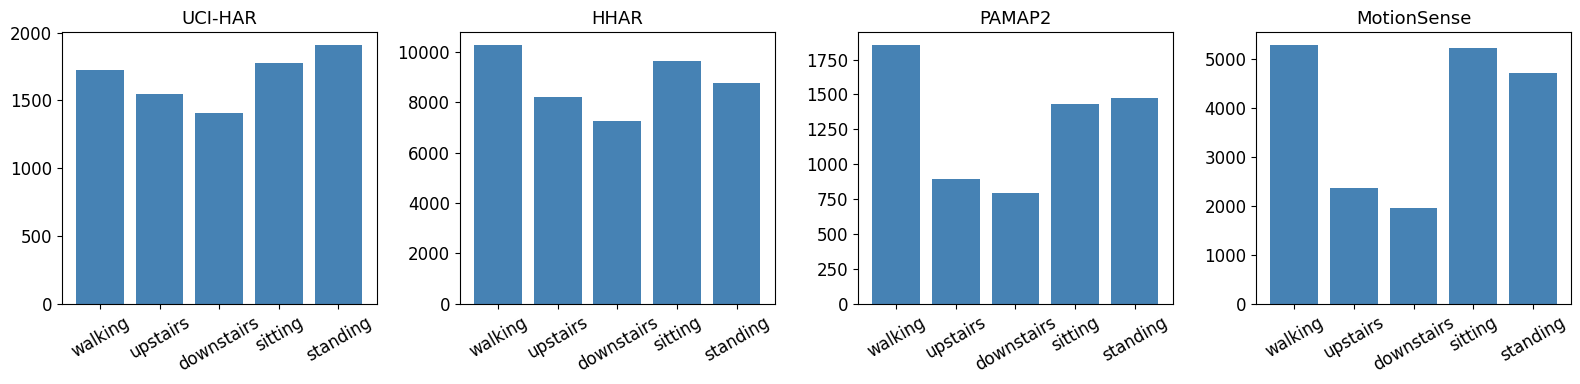

In [25]:
# Class distribution
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, y) in zip(axes, [
    ('UCI-HAR', y_uci), ('HHAR', y_hhar),
    ('PAMAP2',  y_pamp), ('MotionSense', y_ms)
]):
    counts = np.bincount(y, minlength=N_CLASSES)
    ax.bar(CLASS_NAMES, counts, color='steelblue')
    ax.set_title(name, fontsize=13)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/class_distribution.png', dpi=150)
plt.show()


## Build Unified Dataset


In [26]:
datasets = {
    'ucihar':      (X_uci,  y_uci,  s_uci),
    'hhar':        (X_hhar, y_hhar, s_hhar),
    'pamap2':      (X_pamp, y_pamp, s_pamp),
    'motionsense': (X_ms,   y_ms,   s_ms),
}

splits = build_unified_dataset(datasets, val_fraction=0.10, test_fraction=0.20, seed=42)
train_ds, val_ds, test_ds = splits['train'], splits['val'], splits['test']
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Train: 53326  Val: 7428  Test: 17691


## Pretraining

Set `PRETRAIN_EPOCHS = 100` 


In [ ]:
PRETRAIN_EPOCHS = 100  # 10 for quick test, 100 for final
LR = 3e-4

two_view  = TwoViewTransform(aug1='jitter', aug2='scaling')
wk_strong = WeakStrongTransform()

def batch_aug(x, transform):
    v1 = torch.stack([transform(xi)[0] for xi in x])
    v2 = torch.stack([transform(xi)[1] for xi in x])
    return v1, v2


In [28]:
# ── SimCLR ──────────────────────────────────────────────────────────────
print('=== SimCLR ===')
backbone_simclr = ResNet1D(in_channels=6, base_filters=64)
simclr = SimCLR(backbone_simclr, proj_dim=128, temperature=0.1)
loss_simclr = pretrain(simclr, train_loader, PRETRAIN_EPOCHS, lr=LR,
                       device=DEVICE, aug_fn=lambda x: batch_aug(x, two_view), method='simclr')
torch.save(backbone_simclr.state_dict(), f'{CKPT_DIR}/simclr_backbone.pth')
print('Saved.')


=== SimCLR ===


/tmp/ipykernel_452/2103809380.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
/tmp/ipykernel_452/2103809380.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[SIMCLR] Epoch   1/100 | Loss: 0.8605 | Skipped:   0 | LR: 3.00e-04
[SIMCLR] Epoch   5/100 | Loss: 0.4240 | Skipped:   0 | LR: 2.98e-04
[SIMCLR] Epoch  10/100 | Loss: 0.3505 | Skipped:   0 | LR: 2.93e-04
[SIMCLR] Epoch  15/100 | Loss: 0.3194 | Skipped:   0 | LR: 2.84e-04
[SIMCLR] Epoch  20/100 | Loss: 0.3028 | Skipped:   0 | LR: 2.72e-04
[SIMCLR] Epoch  25/100 | Loss: 0.2856 | Skipped:   0 | LR: 2.57e-04
[SIMCLR] Epoch  30/100 | Loss: 0.2771 | Skipped:   0 | LR: 2.39e-04
[SIMCLR] Epoch  35/100 | Loss: 0.2700 | Skipped:   0 | LR: 2.19e-04
[SIMCLR] Epoch  40/100 | Loss: 0.2624 | Skipped:   0 | LR: 1.97e-04
[SIMCLR] Epoch  45/100 | Loss: 0.2596 | Skipped:   0 | LR: 1.75e-04
[SIMCLR] Epoch  50/100 | Loss: 0.2537 | Skipped:   0 | LR: 1.52e-04
[SIMCLR] Epoch  55/100 | Loss: 0.2468 | Skipped:   0 | LR: 1.28e-04
[SIMCLR] Epoch  60/100 | Loss: 0.2440 | Skipped:   0 | LR: 1.06e-04
[SIMCLR] Epoch  65/100 | Loss: 0.2379 | Skipped:   0 | LR: 8.41e-05
[SIMCLR] Epoch  70/100 | Loss: 0.2376 | Skipped:

In [29]:
# ── TS-TCC ───────────────────────────────────────────────────────────────
print('=== TS-TCC ===')
backbone_tstcc = CNN1D(in_channels=6, out_channels=128)
tstcc = TSTCC(backbone_tstcc, context_dim=256, proj_dim=128)
loss_tstcc = pretrain(tstcc, train_loader, PRETRAIN_EPOCHS, lr=LR,
                      device=DEVICE, aug_fn=lambda x: batch_aug(x, wk_strong), method='tstcc')
torch.save(tstcc.state_dict(), f'{CKPT_DIR}/tstcc.pth')
print('Saved.')


=== TS-TCC ===


/tmp/ipykernel_452/2103809380.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
/tmp/ipykernel_452/2103809380.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[TSTCC] Epoch   1/100 | Loss: 9.1194 | Skipped:   0 | LR: 3.00e-04
[TSTCC] Epoch   5/100 | Loss: 6.2923 | Skipped:   0 | LR: 2.98e-04
[TSTCC] Epoch  10/100 | Loss: 5.7490 | Skipped:   0 | LR: 2.93e-04
[TSTCC] Epoch  15/100 | Loss: 5.4559 | Skipped:   0 | LR: 2.84e-04
[TSTCC] Epoch  20/100 | Loss: 5.2727 | Skipped:   0 | LR: 2.72e-04
[TSTCC] Epoch  25/100 | Loss: 5.1203 | Skipped:   0 | LR: 2.57e-04
[TSTCC] Epoch  30/100 | Loss: 5.0149 | Skipped:   0 | LR: 2.39e-04
[TSTCC] Epoch  35/100 | Loss: 4.9263 | Skipped:   0 | LR: 2.19e-04
[TSTCC] Epoch  40/100 | Loss: 4.8572 | Skipped:   0 | LR: 1.97e-04
[TSTCC] Epoch  45/100 | Loss: 4.8105 | Skipped:   0 | LR: 1.75e-04
[TSTCC] Epoch  50/100 | Loss: 4.7353 | Skipped:   0 | LR: 1.52e-04
[TSTCC] Epoch  55/100 | Loss: 4.6987 | Skipped:   0 | LR: 1.28e-04
[TSTCC] Epoch  60/100 | Loss: 4.6638 | Skipped:   0 | LR: 1.06e-04
[TSTCC] Epoch  65/100 | Loss: 4.6391 | Skipped:   0 | LR: 8.41e-05
[TSTCC] Epoch  70/100 | Loss: 4.6073 | Skipped:   0 | LR: 6.42

In [30]:
# ── TF-C ─────────────────────────────────────────────────────────────────
print('=== TF-C ===')
tfc = TFC(in_channels=6, seq_len=128, d_model=64, proj_dim=64)
loss_tfc = pretrain(tfc, train_loader, PRETRAIN_EPOCHS, lr=LR,
                    device=DEVICE, aug_fn=lambda x: batch_aug(x, two_view), method='tfc')
torch.save(tfc.state_dict(), f'{CKPT_DIR}/tfc.pth')
print('Saved.')


=== TF-C ===


/tmp/ipykernel_452/2103809380.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
/tmp/ipykernel_452/2103809380.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[TFC] Epoch   1/100 | Loss: 7.0290 | Skipped:   0 | LR: 3.00e-04
[TFC] Epoch   5/100 | Loss: 3.1521 | Skipped:   0 | LR: 2.98e-04
[TFC] Epoch  10/100 | Loss: 2.5423 | Skipped:   0 | LR: 2.93e-04
[TFC] Epoch  15/100 | Loss: 2.2786 | Skipped:   0 | LR: 2.84e-04
[TFC] Epoch  20/100 | Loss: 2.1162 | Skipped:   0 | LR: 2.72e-04
[TFC] Epoch  25/100 | Loss: 1.9946 | Skipped:   0 | LR: 2.57e-04
[TFC] Epoch  30/100 | Loss: 1.9114 | Skipped:   0 | LR: 2.39e-04
[TFC] Epoch  35/100 | Loss: 1.8457 | Skipped:   0 | LR: 2.19e-04
[TFC] Epoch  40/100 | Loss: 1.8006 | Skipped:   0 | LR: 1.97e-04
[TFC] Epoch  45/100 | Loss: 1.7495 | Skipped:   0 | LR: 1.75e-04
[TFC] Epoch  50/100 | Loss: 1.7244 | Skipped:   0 | LR: 1.52e-04
[TFC] Epoch  55/100 | Loss: 1.6973 | Skipped:   0 | LR: 1.28e-04
[TFC] Epoch  60/100 | Loss: 1.6654 | Skipped:   0 | LR: 1.06e-04
[TFC] Epoch  65/100 | Loss: 1.6528 | Skipped:   0 | LR: 8.41e-05
[TFC] Epoch  70/100 | Loss: 1.6236 | Skipped:   0 | LR: 6.42e-05
[TFC] Epoch  75/100 | Los

SOFTCLT


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast


def soft_ntxent_instance(
    z1: torch.Tensor,
    z2: torch.Tensor,
    x_raw: torch.Tensor,
    rho: float = 1.0,
    temperature: float = 0.1,
) -> torch.Tensor:
    B = z1.shape[0]
    if B < 2:
        return torch.zeros((), device=z1.device, dtype=z1.dtype)

    rho = max(float(rho), 1e-4)
    temperature = max(float(temperature), 1e-4)

    x_flat = x_raw.reshape(B, -1).float()
    x_flat = torch.nan_to_num(x_flat, nan=0.0, posinf=0.0, neginf=0.0)
    x_flat = F.normalize(x_flat, dim=1, eps=1e-6)

    dist2 = torch.cdist(x_flat, x_flat, p=2).pow(2)
    dist2 = torch.nan_to_num(dist2, nan=1e4, posinf=1e4, neginf=1e4)
    dist2 = dist2.clamp(min=0.0, max=1e4)

    W = torch.exp(torch.clamp(-dist2 / (2.0 * rho * rho), min=-50.0, max=0.0))
    W = torch.nan_to_num(W, nan=0.0, posinf=0.0, neginf=0.0)

    z1 = F.normalize(torch.nan_to_num(z1.float(), nan=0.0, posinf=0.0, neginf=0.0), dim=1, eps=1e-6)
    z2 = F.normalize(torch.nan_to_num(z2.float(), nan=0.0, posinf=0.0, neginf=0.0), dim=1, eps=1e-6)
    z = torch.cat([z1, z2], dim=0)

    sim = torch.mm(z, z.T) / temperature
    sim = torch.nan_to_num(sim, nan=-1e9, posinf=1e4, neginf=-1e4)

    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e9)

    soft_targets = torch.zeros(2 * B, 2 * B, device=z.device, dtype=sim.dtype)
    soft_targets[:B, B:] = W
    soft_targets[B:, :B] = W
    soft_targets = soft_targets.masked_fill(mask, 0.0)

    row_sums = soft_targets.sum(dim=1, keepdim=True)
    valid_rows = row_sums.squeeze(1) > 0

    if not valid_rows.any():
        return torch.zeros((), device=z.device, dtype=z.dtype)

    soft_targets = soft_targets / row_sums.clamp_min(1e-8)
    soft_targets = torch.nan_to_num(soft_targets, nan=0.0, posinf=0.0, neginf=0.0)

    log_probs = F.log_softmax(sim, dim=1)
    loss = -(soft_targets * log_probs).sum(dim=1)
    loss = torch.nan_to_num(loss, nan=0.0, posinf=0.0, neginf=0.0)

    return loss[valid_rows].mean()


def soft_ntxent_temporal(
    z_seq: torch.Tensor,
    rho: float = 10.0,
    temperature: float = 0.1,
) -> torch.Tensor:
    B, D, T = z_seq.shape
    if T < 2:
        return torch.zeros((), device=z_seq.device, dtype=z_seq.dtype)

    rho = max(float(rho), 1e-4)
    temperature = max(float(temperature), 1e-4)

    z_seq = torch.nan_to_num(z_seq.float(), nan=0.0, posinf=0.0, neginf=0.0)
    z_seq = F.normalize(z_seq, dim=1, eps=1e-6)
    z_mean = z_seq.mean(dim=0).T

    sim = torch.mm(z_mean, z_mean.T) / temperature
    sim = torch.nan_to_num(sim, nan=-1e9, posinf=1e4, neginf=-1e4)

    mask_diag = torch.eye(T, dtype=torch.bool, device=sim.device)
    sim = sim.masked_fill(mask_diag, -1e9)

    t_idx = torch.arange(T, device=sim.device).float()
    dist_mat = (t_idx[:, None] - t_idx[None, :]).abs()

    v = torch.exp(torch.clamp(-dist_mat / rho, min=-50.0, max=0.0))
    v = v.masked_fill(mask_diag, 0.0)
    v = v / v.sum(dim=1, keepdim=True).clamp_min(1e-8)
    v = torch.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

    log_probs = F.log_softmax(sim, dim=1)
    loss = -(v * log_probs).sum(dim=1)
    loss = torch.nan_to_num(loss, nan=0.0, posinf=0.0, neginf=0.0)

    return loss.mean()


class SoftCLT(nn.Module):
    def __init__(
        self,
        backbone: nn.Module,
        proj_dim: int = 128,
        rho_instance: float = 1.0,
        rho_temporal: float = 10.0,
        lambda_temporal: float = 0.5,
        temp_instance: float = 0.10,
        temp_temporal: float = 0.10,
    ):
        super().__init__()
        self.backbone = backbone
        self.lambda_temporal = lambda_temporal
        self.rho_instance = rho_instance
        self.rho_temporal = rho_temporal
        self.temp_instance = temp_instance
        self.temp_temporal = temp_temporal

        in_dim = getattr(backbone, "out_channels", backbone.out_dim)
        self.projector = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(inplace=True),
            nn.Linear(in_dim, proj_dim),
        )
        self.out_dim = getattr(backbone, "out_dim", in_dim)

    def forward(self, x: torch.Tensor, x_aug: torch.Tensor) -> torch.Tensor:
        seq = self.backbone(x)
        seq_aug = self.backbone(x_aug)

        seq = torch.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
        seq_aug = torch.nan_to_num(seq_aug, nan=0.0, posinf=0.0, neginf=0.0)

        h = seq.mean(dim=-1)
        h_aug = seq_aug.mean(dim=-1)

        z = self.projector(h)
        z_aug = self.projector(h_aug)

        l_instance = soft_ntxent_instance(
            z, z_aug, x, self.rho_instance, self.temp_instance
        )
        l_temporal = soft_ntxent_temporal(
            seq, self.rho_temporal, self.temp_temporal
        )

        loss = l_instance + self.lambda_temporal * l_temporal
        return torch.nan_to_num(loss, nan=0.0, posinf=1e4, neginf=1e4)

    @torch.no_grad()
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone.encode(x)


def pretrain(
    model: nn.Module,
    train_loader,
    n_epochs: int,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
    device: str = "cuda",
    aug_fn=None,
    method: str = "simclr",
    scheduler: str = "cosine",
    use_amp: bool = True,
    verbose: bool = True,
):
    model = model.to(device)

    if method == "softclt":
        lr = min(lr, 1e-4)

    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimiser, T_max=n_epochs, eta_min=lr * 0.01
        )
    else:
        sched = None

    amp_enabled = bool(use_amp and device != "cpu" and method != "softclt")
    scaler = GradScaler(enabled=amp_enabled)
    loss_hist = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0.0
        n_batches = 0
        skipped = 0

        for x, _ in train_loader:
            x = x.to(device)

            if aug_fn is not None:
                with torch.no_grad():
                    v1, v2 = aug_fn(x)
            else:
                v1 = v2 = x

            optimiser.zero_grad(set_to_none=True)

            with autocast(enabled=amp_enabled):
                loss = model(v1, v2)

            if not torch.isfinite(loss):
                skipped += 1
                continue

            scaler.scale(loss).backward()

            if method == "softclt":
                if amp_enabled:
                    scaler.unscale_(optimiser)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimiser)
            scaler.update()

            total_loss += float(loss.detach().cpu())
            n_batches += 1

        if n_batches == 0:
            print(f"[{method.upper()}] Epoch {epoch:3d}/{n_epochs} | all batches skipped")
            loss_hist.append(float("nan"))
            continue

        mean_loss = total_loss / n_batches
        loss_hist.append(mean_loss)

        if sched is not None:
            sched.step()

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(
                f"[{method.upper()}] Epoch {epoch:3d}/{n_epochs} | "
                f"Loss: {mean_loss:.4f} | Skipped: {skipped:3d} | "
                f"LR: {optimiser.param_groups[0]['lr']:.2e}"
            )

    return loss_hist


In [32]:
# ── SoftCLT ──────────────────────────────────────────────────────────────
print('=== SoftCLT ===')
backbone_soft = CNN1D(in_channels=6, out_channels=128)
softclt = SoftCLT(
    backbone_soft,
    proj_dim=128,
    rho_instance=1.0,
    rho_temporal=10.0,
    lambda_temporal=0.5,
    temp_instance=0.10,
    temp_temporal=0.10,
)

loss_softclt = pretrain(
    softclt,
    train_loader,
    PRETRAIN_EPOCHS,
    lr=1e-4,              # important
    device=DEVICE,
    aug_fn=lambda x: batch_aug(x, two_view),
    method="softclt",
    use_amp=False,        # important
)

torch.save(softclt.state_dict(), f'{CKPT_DIR}/softclt.pth')
print('Saved.')


=== SoftCLT ===


/tmp/ipykernel_452/576389377.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
/tmp/ipykernel_452/576389377.py:203: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[SOFTCLT] Epoch   1/100 | Loss: 8.5814 | Skipped:   0 | LR: 1.00e-04
[SOFTCLT] Epoch   5/100 | Loss: 8.5266 | Skipped:   0 | LR: 9.94e-05
[SOFTCLT] Epoch  10/100 | Loss: 8.5239 | Skipped:   0 | LR: 9.76e-05
[SOFTCLT] Epoch  15/100 | Loss: 8.5229 | Skipped:   0 | LR: 9.46e-05
[SOFTCLT] Epoch  20/100 | Loss: 8.5221 | Skipped:   0 | LR: 9.05e-05
[SOFTCLT] Epoch  25/100 | Loss: 8.5215 | Skipped:   0 | LR: 8.55e-05
[SOFTCLT] Epoch  30/100 | Loss: 8.5211 | Skipped:   0 | LR: 7.96e-05
[SOFTCLT] Epoch  35/100 | Loss: 8.5208 | Skipped:   0 | LR: 7.30e-05
[SOFTCLT] Epoch  40/100 | Loss: 8.5206 | Skipped:   0 | LR: 6.58e-05
[SOFTCLT] Epoch  45/100 | Loss: 8.5202 | Skipped:   0 | LR: 5.82e-05
[SOFTCLT] Epoch  50/100 | Loss: 8.5202 | Skipped:   0 | LR: 5.05e-05
[SOFTCLT] Epoch  55/100 | Loss: 8.5198 | Skipped:   0 | LR: 4.28e-05
[SOFTCLT] Epoch  60/100 | Loss: 8.5197 | Skipped:   0 | LR: 3.52e-05
[SOFTCLT] Epoch  65/100 | Loss: 8.5194 | Skipped:   0 | LR: 2.80e-05
[SOFTCLT] Epoch  70/100 | Loss: 8.

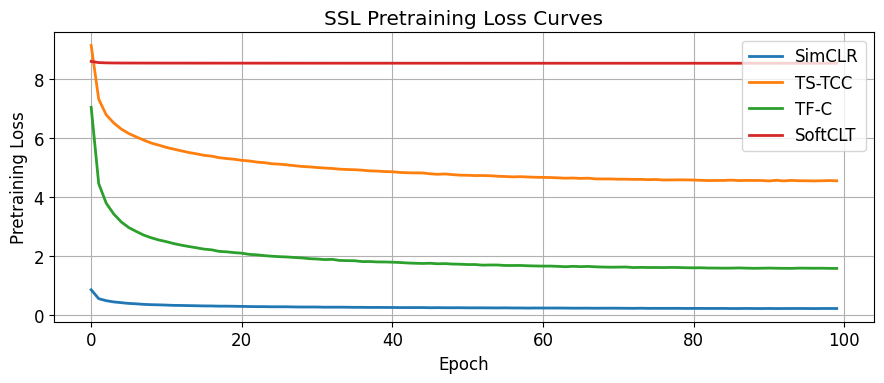

In [33]:
# Loss curves
plt.figure(figsize=(9, 4))
for name, hist in [('SimCLR', loss_simclr), ('TS-TCC', loss_tstcc),
                   ('TF-C',   loss_tfc),    ('SoftCLT', loss_softclt)]:
    plt.plot(hist, label=name, linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Pretraining Loss')
plt.title('SSL Pretraining Loss Curves')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pretrain_loss.png', dpi=150)
plt.show()


## Downstream Evaluation — Linear Probe + Fine-Tune


In [34]:
RESULTS = {}
models_to_eval = [
    # ('SimCLR',  backbone_simclr),
    ('SimCLR',  simclr),
    ('TS-TCC',  tstcc),
    ('TF-C',    tfc),
    ('SoftCLT', softclt),
]

for method_name, model in models_to_eval:
    print(f'\n=== {method_name} — Linear Probe ===')
    result = linear_probe_sklearn(model, train_loader, test_loader, val_loader, device=DEVICE)
    eval_out = full_evaluation(
        result['logits_test'], result['labels_test'],
        result['logits_cal'],  result['labels_cal'],
        alpha=0.10, n_bins=15,
    )
    RESULTS[f'{method_name}_linear'] = eval_out
    conf = eval_out['conformal']
    print(f"  Acc={eval_out['raw_acc']:.4f}  F1={eval_out['raw_f1']:.4f}  "
          f"ECE_raw={eval_out['raw_ece']:.4f}  ECE_ts={eval_out['ts_ece']:.4f}  "
          f"T={eval_out['temperature']:.3f}  Coverage={conf['empirical_coverage']:.3f}  "
          f"AvgSet={conf['avg_set_size']:.2f}")



=== SimCLR — Linear Probe ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.6451  F1=0.6376  ECE_raw=0.1666  ECE_ts=0.0858  T=1.586  Coverage=0.820  AvgSet=1.48

=== TS-TCC — Linear Probe ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.7465  F1=0.7388  ECE_raw=0.1223  ECE_ts=0.0347  T=2.187  Coverage=0.895  AvgSet=1.50

=== TF-C — Linear Probe ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.6692  F1=0.6568  ECE_raw=0.1544  ECE_ts=0.0733  T=1.592  Coverage=0.828  AvgSet=1.46

=== SoftCLT — Linear Probe ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.6797  F1=0.6729  ECE_raw=0.1136  ECE_ts=0.0311  T=1.733  Coverage=0.886  AvgSet=1.59


In [35]:
for method_name, model in models_to_eval:
    print(f'\n=== {method_name} — Fine-Tune ===')

    # Fix for SimCLR model: Dynamically add 'out_dim' if missing
    if method_name == 'SimCLR' and not hasattr(model, 'out_dim'):
        model.out_dim = model.backbone.out_dim

    result = finetune(model, train_loader, test_loader, val_loader,
                      n_classes=N_CLASSES, n_epochs=50, lr=1e-3,
                      freeze_encoder=False, device=DEVICE, verbose=False)
    eval_out = full_evaluation(
        result['logits_test'], result['labels_test'],
        result['logits_cal'],  result['labels_cal'],
    )
    RESULTS[f'{method_name}_finetune'] = eval_out
    conf = eval_out['conformal']
    print(f"  Acc={eval_out['raw_acc']:.4f}  F1={eval_out['raw_f1']:.4f}  "
          f"ECE_raw={eval_out['raw_ece']:.4f}  ECE_ts={eval_out['ts_ece']:.4f}  "
          f"Coverage={conf['empirical_coverage']:.3f}")



=== SimCLR — Fine-Tune ===
  Acc=0.6872  F1=0.6824  ECE_raw=0.1622  ECE_ts=0.0587  Coverage=0.866

=== TS-TCC — Fine-Tune ===
  Acc=0.7252  F1=0.7276  ECE_raw=0.1553  ECE_ts=0.0566  Coverage=0.881

=== TF-C — Fine-Tune ===
  Acc=0.7090  F1=0.6974  ECE_raw=0.1700  ECE_ts=0.0686  Coverage=0.864

=== SoftCLT — Fine-Tune ===
  Acc=0.7157  F1=0.7025  ECE_raw=0.1047  ECE_ts=0.0557  Coverage=0.883


## Reliability Diagrams


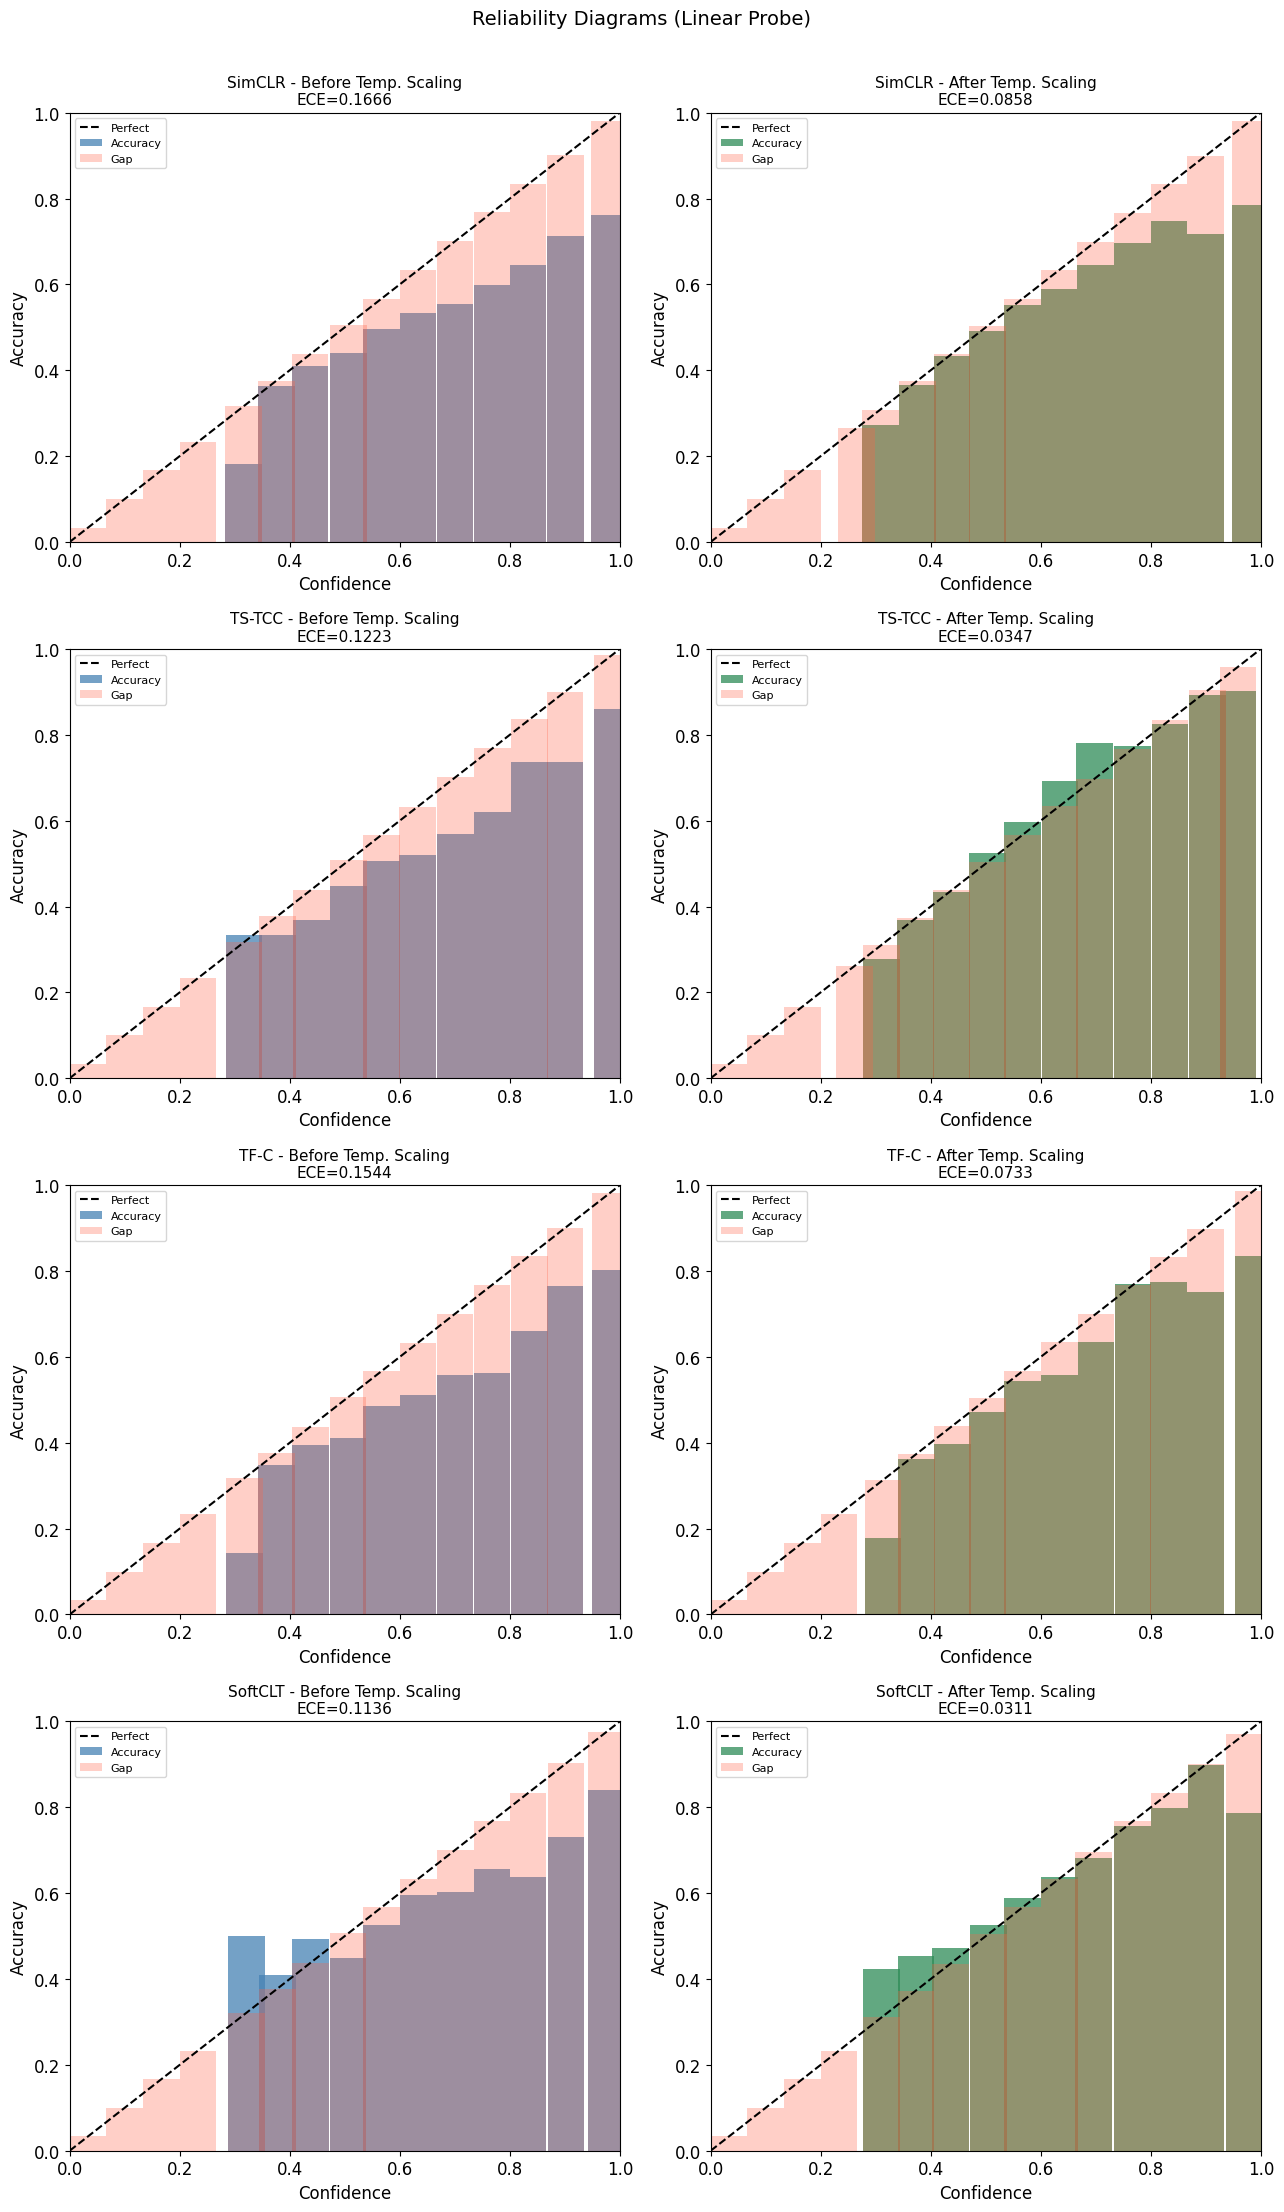

In [36]:
def plot_reliability(ax, rd, title, color='steelblue'):
    bc, ba, ece = rd['bin_confidences'], rd['bin_accuracies'], rd['ece']
    w = 1.0 / len(bc)
    ax.bar(bc, ba, width=w, alpha=0.75, color=color, align='center', label='Accuracy')
    ax.bar(bc, bc, width=w, alpha=0.30, color='tomato', align='center', label='Gap')
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{title}\nECE={ece:.4f}', fontsize=11)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(4, 2, figsize=(13, 22))
for row, method_name in enumerate(['SimCLR','TS-TCC','TF-C','SoftCLT']):
    key = f'{method_name}_linear'
    if key not in RESULTS: continue
    plot_reliability(axes[row,0], RESULTS[key]['reliability_raw'],
                     f'{method_name} - Before Temp. Scaling', 'steelblue')
    plot_reliability(axes[row,1], RESULTS[key]['reliability_ts'],
                     f'{method_name} - After Temp. Scaling',  'seagreen')
plt.suptitle('Reliability Diagrams (Linear Probe)', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()


## Results Summary Table


In [37]:
rows = []
for key, r in RESULTS.items():
    conf = r['conformal']
    rows.append({
        'Method':     key,
        'Acc':        f"{r['raw_acc']:.4f}",
        'Macro-F1':   f"{r['raw_f1']:.4f}",
        'ECE (raw)':  f"{r['raw_ece']:.4f}",
        'ECE (T-sc)': f"{r['ts_ece']:.4f}",
        'T':          f"{r['temperature']:.3f}",
        'NLL':        f"{r['raw_nll']:.4f}",
        'Brier':      f"{r['raw_brier']:.4f}",
        'Coverage':   f"{conf['empirical_coverage']:.3f}",
        'Avg Set':    f"{conf['avg_set_size']:.2f}",
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(f'{RES_DIR}/summary_table.csv', index=False)
print(f'Saved to {RES_DIR}/summary_table.csv')


          Method    Acc Macro-F1 ECE (raw) ECE (T-sc)     T    NLL  Brier Coverage Avg Set
   SimCLR_linear 0.6451   0.6376    0.1666     0.0858 1.586 1.0802 0.5266    0.820    1.48
   TS-TCC_linear 0.7465   0.7388    0.1223     0.0347 2.187 0.8448 0.3895    0.895    1.50
     TF-C_linear 0.6692   0.6568    0.1544     0.0733 1.592 1.1939 0.4931    0.828    1.46
  SoftCLT_linear 0.6797   0.6729    0.1136     0.0311 1.733 0.9674 0.4601    0.886    1.59
 SimCLR_finetune 0.6872   0.6824    0.1622     0.0587 2.147 1.1337 0.4876    0.866    1.63
 TS-TCC_finetune 0.7252   0.7276    0.1553     0.0566 2.076 0.9501 0.4352    0.881    1.49
   TF-C_finetune 0.7090   0.6974    0.1700     0.0686 2.651 1.3478 0.4731    0.864    1.60
SoftCLT_finetune 0.7157   0.7025    0.1047     0.0557 1.669 0.8386 0.4146    0.883    1.50
Saved to /content/drive/MyDrive/Project_Activity_detection/results_2_exact/summary_table.csv


## Cross-Dataset Transfer
Pretrain on UCI+HHAR+PAMAP2, evaluate on MotionSense.


In [38]:
transfer = build_transfer_splits(
    source_datasets={
        'ucihar': (X_uci,  y_uci,  s_uci),
        'hhar':   (X_hhar, y_hhar, s_hhar),
        'pamap2': (X_pamp, y_pamp, s_pamp),
    },
    target_dataset = (X_ms, y_ms, s_ms),
    target_name    = 'motionsense',
    val_fraction   = 0.10,
)
cal_ms  = DataLoader(transfer['cal'],  batch_size=BATCH_SIZE)
test_ms = DataLoader(transfer['test'], batch_size=BATCH_SIZE)
src_ms  = DataLoader(transfer['source'], batch_size=BATCH_SIZE, shuffle=True)
print(f'Cal: {len(transfer["cal"])}  Test: {len(transfer["test"])}')


Cal: 2685  Test: 16829


In [39]:
TRANSFER_RESULTS = {}
for method_name, model in models_to_eval:
    print(f'\n=== Transfer: {method_name} → MotionSense ===')
    result = linear_probe_sklearn(model, src_ms, test_ms, cal_ms, device=DEVICE)
    eval_out = full_evaluation(
        result['logits_test'], result['labels_test'],
        result['logits_cal'],  result['labels_cal'],
    )
    TRANSFER_RESULTS[method_name] = eval_out
    conf = eval_out['conformal']
    print(f"  Acc={eval_out['raw_acc']:.4f}  ECE={eval_out['raw_ece']:.4f}  "
          f"Coverage={conf['empirical_coverage']:.3f} (target 0.90)  "
          f"AvgSet={conf['avg_set_size']:.2f}")



=== Transfer: SimCLR → MotionSense ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.4073  ECE=0.4461  Coverage=0.871 (target 0.90)  AvgSet=2.33

=== Transfer: TS-TCC → MotionSense ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.4623  ECE=0.3684  Coverage=0.858 (target 0.90)  AvgSet=2.21

=== Transfer: TF-C → MotionSense ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.4038  ECE=0.4057  Coverage=0.859 (target 0.90)  AvgSet=2.23

=== Transfer: SoftCLT → MotionSense ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc=0.4475  ECE=0.3865  Coverage=0.825 (target 0.90)  AvgSet=2.43


## Final Completion Analyses

These sections complete the remaining proposal items: a stabilized `SoftCLT` rerun, transition-focused reliability analysis, and a full leave-one-dataset-out transfer matrix.


In [40]:
# SoftCLT is already using the stable implementation above.

import copy
from sklearn.metrics import accuracy_score, f1_score
from IPython.display import display


## Stable SoftCLT Re-Run

This section retrains `SoftCLT` with a numerically safer loss and optimizer setup so it can be compared more fairly against the other SSL methods.


In [41]:
print('Stable SoftCLT is already active in this notebook; no separate rerun is required.')

COMPLETE_MODELS = models_to_eval


Stable SoftCLT is already active in this notebook; no separate rerun is required.


## Transition-Focused Reliability Analysis

This section measures model behavior near ambiguous activity boundaries by comparing transition windows against non-transition windows on the test split.


In [42]:
# Reconstruct the unified arrays in the same order used before random train/val/test splitting.

def concatenate_unified_arrays(datasets: dict) -> dict:
    all_X, all_y, all_sub, all_src = [], [], [], []
    subj_offset = 0
    for name, (X, y, subjects) in datasets.items():
        src_id = DATASET_IDS[name]
        all_X.append(X)
        all_y.append(y)
        all_sub.append(subjects + subj_offset)
        all_src.append(np.full(len(y), src_id, dtype=np.int64))
        subj_offset += int(subjects.max()) + 1
    return {
        'X': np.concatenate(all_X, axis=0),
        'y': np.concatenate(all_y, axis=0),
        'subjects': np.concatenate(all_sub, axis=0),
        'sources': np.concatenate(all_src, axis=0),
    }


def compute_transition_mask(y: np.ndarray, subjects: np.ndarray, sources: np.ndarray, radius: int = 2) -> np.ndarray:
    mask = np.zeros(len(y), dtype=bool)
    start = 0
    while start < len(y):
        end = start + 1
        while end < len(y) and subjects[end] == subjects[start] and sources[end] == sources[start]:
            end += 1

        seg_y = y[start:end]
        change_points = np.where(seg_y[1:] != seg_y[:-1])[0]
        for boundary in change_points:
            lo = max(0, boundary - radius + 1)
            hi = min(len(seg_y), boundary + radius + 1)
            mask[start + lo:start + hi] = True
        start = end
    return mask


def simple_ece_from_logits(logits: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    probs = torch.softmax(torch.as_tensor(logits), dim=1).cpu().numpy()
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(np.float32)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        if hi == 1.0:
            sel = (conf >= lo) & (conf <= hi)
        else:
            sel = (conf >= lo) & (conf < hi)
        if not np.any(sel):
            continue
        ece += abs(acc[sel].mean() - conf[sel].mean()) * sel.mean()
    return float(ece)


def subset_metrics(logits: np.ndarray, labels: np.ndarray, mask: np.ndarray, method: str, split_name: str, dataset_name: str) -> dict:
    logits_sub = logits[mask]
    labels_sub = labels[mask]
    probs = torch.softmax(torch.as_tensor(logits_sub), dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)
    conf = probs.max(axis=1)
    acc = accuracy_score(labels_sub, preds)
    macro_f1 = f1_score(labels_sub, preds, average='macro')
    ece = simple_ece_from_logits(logits_sub, labels_sub)
    return {
        'Method': method,
        'Split': split_name,
        'Dataset': dataset_name,
        'N': int(mask.sum()),
        'Acc': float(acc),
        'Macro-F1': float(macro_f1),
        'ECE': float(ece),
        'Avg Confidence': float(conf.mean()),
        'Overconfidence Gap': float(conf.mean() - acc),
    }


analysis_models = COMPLETE_MODELS if 'COMPLETE_MODELS' in globals() else models_to_eval
transition_outputs = {}
for method_name, model in analysis_models:
    print(f'Collecting linear-probe outputs for transition analysis: {method_name}')
    transition_outputs[method_name] = linear_probe_sklearn(
        model,
        train_loader,
        test_loader,
        val_loader,
        device=DEVICE,
    )

full_arrays = concatenate_unified_arrays(datasets)
full_transition_mask = compute_transition_mask(
    full_arrays['y'],
    full_arrays['subjects'],
    full_arrays['sources'],
    radius=2,
)

test_idx = splits['meta']['test_idx']
test_transition_mask = full_transition_mask[test_idx]
test_source_ids = full_arrays['sources'][test_idx]
id_to_name = {v: k for k, v in DATASET_IDS.items()}

transition_rows = []
for method_name, out in transition_outputs.items():
    logits = out['logits_test']
    labels = out['labels_test']

    all_mask = np.ones(len(labels), dtype=bool)
    stable_mask = ~test_transition_mask

    transition_rows.append(subset_metrics(logits, labels, all_mask, method_name, 'all', 'overall'))
    if test_transition_mask.any():
        transition_rows.append(subset_metrics(logits, labels, test_transition_mask, method_name, 'transition', 'overall'))
    if stable_mask.any():
        transition_rows.append(subset_metrics(logits, labels, stable_mask, method_name, 'stable', 'overall'))

    for src_id, dataset_name in sorted(id_to_name.items()):
        ds_mask = test_source_ids == src_id
        if not ds_mask.any():
            continue
        ds_trans = ds_mask & test_transition_mask
        ds_stable = ds_mask & stable_mask
        if ds_trans.any():
            transition_rows.append(subset_metrics(logits, labels, ds_trans, method_name, 'transition', dataset_name))
        if ds_stable.any():
            transition_rows.append(subset_metrics(logits, labels, ds_stable, method_name, 'stable', dataset_name))

transition_df = pd.DataFrame(transition_rows)
transition_df = transition_df.sort_values(['Dataset', 'Method', 'Split']).reset_index(drop=True)
display(transition_df)
transition_df.to_csv(f'{RES_DIR}/transition_reliability_summary.csv', index=False)
print(f'Saved to {RES_DIR}/transition_reliability_summary.csv')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Method,Split,Dataset,N,Acc,Macro-F1,ECE,Avg Confidence,Overconfidence Gap
0,SimCLR,stable,hhar,9850,0.589137,0.583769,0.234766,0.823903,0.234766
1,SimCLR,transition,hhar,220,0.600000,0.596580,0.243216,0.837502,0.237502
2,SoftCLT,stable,hhar,9850,0.616751,0.616067,0.202337,0.819065,0.202314
3,SoftCLT,transition,hhar,220,0.609091,0.613413,0.229241,0.830423,0.221332
4,TF-C,stable,hhar,9850,0.607208,0.595158,0.231762,0.838970,0.231762
5,TF-C,transition,hhar,220,0.613636,0.601178,0.232083,0.837802,0.224166
6,TS-TCC,stable,hhar,9850,0.760305,0.745999,0.141058,0.901182,0.140877
7,TS-TCC,transition,hhar,220,0.731818,0.724742,0.179167,0.902677,0.170858
8,SimCLR,stable,motionsense,4202,0.732508,0.705358,0.086743,0.819047,0.086538
9,SoftCLT,stable,motionsense,4202,0.823417,0.815205,0.052584,0.799442,-0.023975


Saved to /content/drive/MyDrive/Project_Activity_detection/results_2_exact/transition_reliability_summary.csv


,Method,Split,Dataset,N,Acc,Macro-F1,ECE,Avg Confidence,Overconfidence Gap
13,SimCLR,stable,overall,17171,0.643061,0.635047,0.168735,0.811796,0.168735
14,SimCLR,transition,overall,520,0.596154,0.596607,0.201196,0.797350,0.201196
16,SoftCLT,stable,overall,17171,0.672471,0.668798,0.123667,0.794007,0.121536
17,SoftCLT,transition,overall,520,0.615385,0.615585,0.173180,0.779754,0.164370
19,TF-C,stable,overall,17171,0.672063,0.659144,0.152030,0.824094,0.152030
20,TF-C,transition,overall,520,0.576923,0.574228,0.214853,0.787007,0.210084
22,TS-TCC,stable,overall,17171,0.751092,0.743307,0.120201,0.871293,0.120201
23,TS-TCC,transition,overall,520,0.686538,0.683896,0.160076,0.846615,0.160076


<Figure size 1000x400 with 0 Axes>

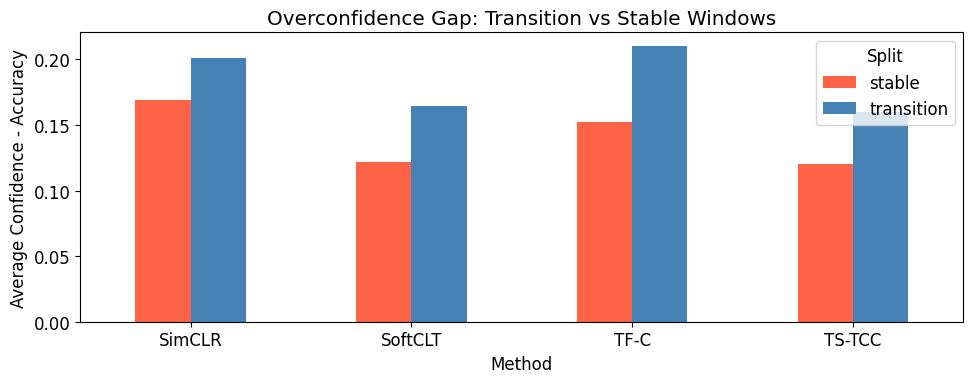

In [43]:
# Compact view of the proposal-critical comparison: transition vs. stable windows.

overall_transition_df = transition_df[
    (transition_df['Dataset'] == 'overall') &
    (transition_df['Split'].isin(['transition', 'stable']))
].copy()

display(overall_transition_df)

plt.figure(figsize=(10, 4))
plot_df = overall_transition_df.pivot(index='Method', columns='Split', values='Overconfidence Gap')
plot_df.plot(kind='bar', figsize=(10, 4), rot=0, color=['tomato', 'steelblue'])
plt.ylabel('Average Confidence - Accuracy')
plt.title('Overconfidence Gap: Transition vs Stable Windows')
plt.tight_layout()
plt.show()


## Full Cross-Dataset Transfer Matrix

This section evaluates all leave-one-dataset-out transfer directions instead of only a single target dataset.


In [44]:
all_transfer_rows = []
all_datasets = {
    'ucihar': (X_uci, y_uci, s_uci),
    'hhar': (X_hhar, y_hhar, s_hhar),
    'pamap2': (X_pamp, y_pamp, s_pamp),
    'motionsense': (X_ms, y_ms, s_ms),
}

analysis_models = COMPLETE_MODELS if 'COMPLETE_MODELS' in globals() else models_to_eval

for target_name, target_dataset in all_datasets.items():
    source_datasets = {k: v for k, v in all_datasets.items() if k != target_name}
    print(f'\n=== Full transfer target: {target_name} ===')
    transfer = build_transfer_splits(
        source_datasets=source_datasets,
        target_dataset=target_dataset,
        target_name=target_name,
        val_fraction=0.10,
    )

    cal_loader_target = DataLoader(transfer['cal'], batch_size=BATCH_SIZE)
    test_loader_target = DataLoader(transfer['test'], batch_size=BATCH_SIZE)
    source_loader = DataLoader(transfer['source'], batch_size=BATCH_SIZE, shuffle=True)

    for method_name, model in analysis_models:
        print(f'  {method_name} -> {target_name}')
        result = linear_probe_sklearn(model, source_loader, test_loader_target, cal_loader_target, device=DEVICE)
        eval_out = full_evaluation(
            result['logits_test'], result['labels_test'],
            result['logits_cal'], result['labels_cal'],
        )
        conf = eval_out['conformal']
        all_transfer_rows.append({
            'Target': target_name,
            'Method': method_name,
            'Acc': float(eval_out['raw_acc']),
            'Macro-F1': float(eval_out['raw_f1']),
            'ECE (raw)': float(eval_out['raw_ece']),
            'ECE (T-sc)': float(eval_out['ts_ece']),
            'NLL': float(eval_out['raw_nll']),
            'Brier': float(eval_out['raw_brier']),
            'Coverage': float(conf['empirical_coverage']),
            'Avg Set': float(conf['avg_set_size']),
        })

full_transfer_df = pd.DataFrame(all_transfer_rows)
full_transfer_df = full_transfer_df.sort_values(['Target', 'Method']).reset_index(drop=True)
display(full_transfer_df)
full_transfer_df.to_csv(f'{RES_DIR}/full_transfer_matrix.csv', index=False)
print(f'Saved to {RES_DIR}/full_transfer_matrix.csv')

display(full_transfer_df.pivot(index='Target', columns='Method', values='Acc'))



=== Full transfer target: ucihar ===
  SimCLR -> ucihar


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  TS-TCC -> ucihar


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  TF-C -> ucihar


...

  SoftCLT -> motionsense


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Target,Method,Acc,Macro-F1,ECE (raw),ECE (T-sc),NLL,Brier,Coverage,Avg Set
0,hhar,SimCLR,0.221720,0.189612,0.666009,0.082179,7.285933,1.394249,0.812098,3.566156
1,hhar,SoftCLT,0.125268,0.081506,0.866485,0.256643,18.889380,1.737816,0.957708,4.792266
2,hhar,TF-C,0.393389,0.252311,0.521394,0.142594,7.223760,1.084035,0.931776,4.385043
3,hhar,TS-TCC,0.122409,0.054279,0.828934,0.116740,10.866444,1.676386,0.839944,4.307912
4,motionsense,SimCLR,0.407154,0.335201,0.445790,0.103101,3.345402,1.012936,0.872304,2.328005
5,motionsense,SoftCLT,0.445659,0.396282,0.388133,0.241396,4.707151,0.911829,0.824529,2.421415
6,motionsense,TF-C,0.403233,0.349910,0.407692,0.119826,2.640883,0.952550,0.858399,2.229841
7,motionsense,TS-TCC,0.461941,0.425237,0.369021,0.119553,3.299903,0.917283,0.859528,2.211361
8,pamap2,SimCLR,0.582197,0.480727,0.274227,0.050010,1.443730,0.649743,0.929110,2.476849
9,pamap2,SoftCLT,0.307789,0.183047,0.611682,0.082209,15.216132,1.308503,0.927674,3.718234


Saved to /content/drive/MyDrive/Project_Activity_detection/results_2_exact/full_transfer_matrix.csv


Method,SimCLR,SoftCLT,TF-C,TS-TCC
Target,,,,
hhar,0.221720,0.125268,0.393389,0.122409
motionsense,0.407154,0.445659,0.403233,0.461941
pamap2,0.582197,0.307789,0.332915,0.377064
ucihar,0.378159,0.352221,0.385475,0.410881
